# AI CV Analyzer — Complete ML Pipeline
## BTS Applied ML 2026

This notebook covers **two distinct pipelines**:

| Pipeline | Task | Type |
|---|---|---|
| **Pipeline 1** | Job Category Classification | Multi-class text classification (24 classes) |
| **Pipeline 2** | CV ↔ Job Matching | Information retrieval (cosine similarity) |

Each pipeline is evaluated independently with multiple models and metrics.

In [1]:
# ── Run this cell FIRST — installs all required packages ──────────────────

# Kaggle dataset download
%pip install "kagglehub==0.3.4"

# Deep Learning (BiLSTM, GRU, AttentionBiLSTM, TextCNN)
%pip install torch>=2.0.0

# Classical ML (LogReg, ComplementNB, RandomForest, LinearSVC,
#               CalibratedClassifierCV, FeatureUnion, TfidfVectorizer)
%pip install scikit-learn>=1.3.0 joblib>=1.3.0

# Sparse matrix operations — used for combining word+char TF-IDF features
%pip install scipy>=1.10.0

# Data processing
%pip install pandas>=2.0.0 numpy>=1.24.0 nltk>=3.8.0

# Visualisation
%pip install matplotlib>=3.7.0 seaborn>=0.12.0 plotly>=5.15.0

# PDF extraction (used in Streamlit app)
%pip install pdfplumber>=0.10.0 PyMuPDF>=1.24.0

# Utilities
%pip install tqdm>=4.65.0 wordcloud>=1.9.0

# NLTK data (stopwords + tokenizer)
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
print("All packages installed.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All packages installed.


## 0. Setup & Imports

In [2]:
import sys, os, warnings, time
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity

from src.dataset import (load_dataset, load_job_descriptions, prepare_data,
                          clean_text, Vocabulary, ResumeDataset)
from src.model import LSTMClassifier, GRUClassifier, count_parameters
from src.train import train_baseline, train_deep
from src.evaluate import plot_training_curves

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("All imports OK")
print(f"PyTorch: {torch.__version__}")

All imports OK
PyTorch: 2.6.0+cpu


## 1. Download Datasets (Kaggle via kagglehub)

In [3]:
import kagglehub, glob

print("Downloading resume dataset...")
resume_dir = kagglehub.dataset_download('snehaanbhawal/resume-dataset')
RESUME_CSV = glob.glob(os.path.join(resume_dir, '**', '*.csv'), recursive=True)[0]
print(f"  Resume CSV: {RESUME_CSV}")

print("Downloading job descriptions dataset...")
jobs_dir = kagglehub.dataset_download('ravindrasinghrana/job-description-dataset')
JOBS_CSV = glob.glob(os.path.join(jobs_dir, '**', '*.csv'), recursive=True)[0]
print(f"  Jobs CSV: {JOBS_CSV}")

  Resume CSV: C:\Users\MSI\.cache\kagglehub\datasets\snehaanbhawal\resume-dataset\versions\1\Resume\Resume.csv
  Jobs CSV: C:\Users\MSI\.cache\kagglehub\datasets\ravindrasinghrana\job-description-dataset\versions\1\job_descriptions.csv


## 2. Dataset Exploration

### Resume Dataset (used for Pipeline 1)

In [4]:
df = load_dataset(RESUME_CSV)
print(f"Shape: {df.shape}")
print(f"Categories ({df['Category'].nunique()}):\n")
counts = df['Category'].value_counts()
for cat, n in counts.items():
    print(f"  {cat:<30} {n:>4} resumes")

[Dataset] Loaded 2484 resumes, 24 categories
          Categories: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Shape: (2484, 2)
Categories (24):

  INFORMATION-TECHNOLOGY          120 resumes
  BUSINESS-DEVELOPMENT            120 resumes
  ADVOCATE                        118 resumes
  CHEF                            118 resumes
  ENGINEERING                     118 resumes
  ACCOUNTANT                      118 resumes
  FINANCE                         118 resumes
  FITNESS                         117 resumes
  AVIATION                        117 resumes
  SALES                           116 resumes
  BANKING                         115 resumes
  HEALTHCARE                      115 resumes
  CONSULTANT               

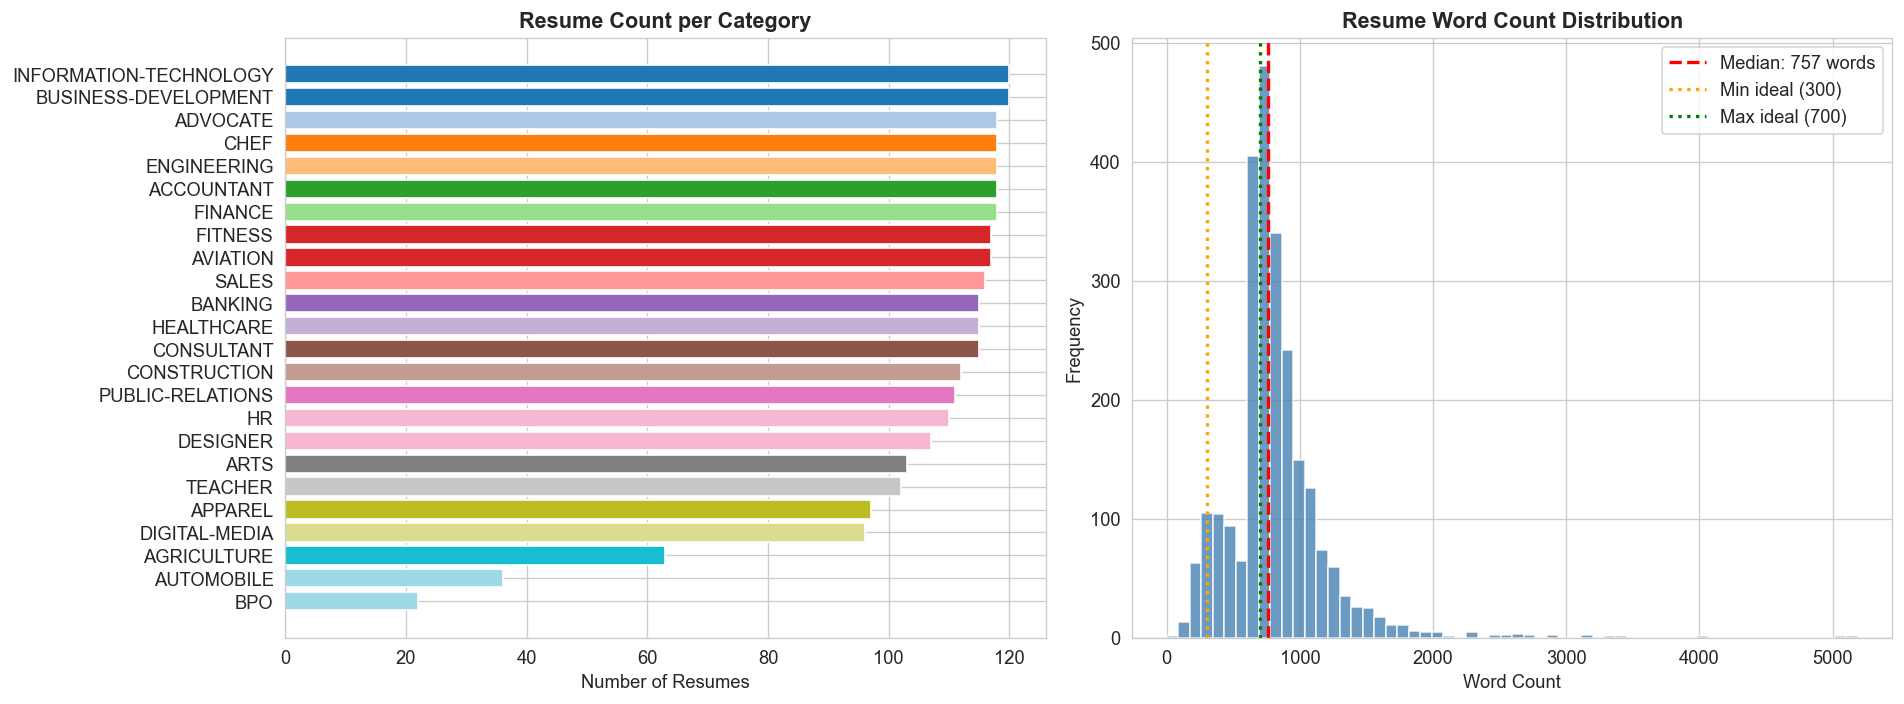

Word count: min=0 | median=757 | max=5190


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Class distribution
counts = df['Category'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_title('Resume Count per Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Resumes')
axes[0].invert_yaxis()

# Word count distribution
df['word_count'] = df['Resume_str'].str.split().str.len()
axes[1].hist(df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: {df['word_count'].median():.0f} words")
axes[1].axvline(300, color='orange', linestyle=':', linewidth=2, label='Min ideal (300)')
axes[1].axvline(700, color='green', linestyle=':', linewidth=2, label='Max ideal (700)')
axes[1].set_title('Resume Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Word count: min={df['word_count'].min()} | median={df['word_count'].median():.0f} | max={df['word_count'].max()}")

## 3. Text Preprocessing

Pipeline applied to every resume:
1. Lowercase
2. Remove URLs and emails
3. Replace numbers with `NUM` token
4. Remove punctuation
5. Remove English stopwords
6. Remove tokens shorter than 3 characters

In [6]:
sample = df.iloc[5]['Resume_str']
print("=== RAW TEXT (first 500 chars) ===")
print(sample[:500])
print()
print("=== AFTER PREPROCESSING (first 500 chars) ===")
print(clean_text(sample)[:500])

=== RAW TEXT (first 500 chars) ===
         HR GENERALIST       Summary     Dedicated and focused Administrative Assistant who excels at prioritizing, completing multiple tasks simultaneously and following through to achieve project goals. Seeking a role of increased responsibility and authority.       Highlights         Microsoft Office proficiency  Excel spreadsheets  Meticulous attention to detail  Results-oriented  Self-directed      Time management  Professional and mature  Self-starter  Legal administrative support         

=== AFTER PREPROCESSING (first 500 chars) ===
generalist summary dedicated focused administrative assistant excels prioritizing completing multiple tasks simultaneously following achieve project goals seeking role increased responsibility authority highlights microsoft office proficiency excel spreadsheets meticulous attention detail results oriented self directed time management professional mature self starter legal administrative support experience NUM NUM

In [7]:
# Vocabulary statistics after preprocessing
X_tr, X_te, y_tr, y_te, le = prepare_data(df, max_samples=2000)

all_words = [w for text in X_tr for w in text.split()]
word_freq = Counter(all_words)
print(f"Train samples  : {len(X_tr)}")
print(f"Test samples   : {len(X_te)}")
print(f"Classes        : {len(le.classes_)}")
print(f"Unique tokens  : {len(word_freq)}")
print(f"Top 15 words   : {[w for w,_ in word_freq.most_common(15)]}")
print(f"Class names    : {le.classes_.tolist()}")

[Data] Train=1491  Test=373  Classes=24
Train samples  : 1491
Test samples   : 373
Classes        : 24
Unique tokens  : 28571
Top 15 words   : ['NUM', 'state', 'company', 'city', 'management', 'name', 'sales', 'business', 'customer', 'skills', 'service', 'new', 'team', 'experience', 'training']
Class names    : ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


---
# PIPELINE 1 — Job Category Classification

**Goal:** Given a resume text, predict the job category (24 possible classes).

**Input:** Raw resume text (plain text or extracted from PDF)
**Output:** Predicted job category + confidence score
**Metric chosen:** Weighted F1-score (handles class imbalance in 24 classes)

## Models Tested

### Classical ML (scikit-learn)
| # | Model | Rationale |
|---|---|---|
| 1 | TF-IDF + Logistic Regression | Strong linear baseline for text |
| 2 | TF-IDF + Complement Naive Bayes | Fast probabilistic model, good for text imbalance |
| 3 | TF-IDF + Random Forest | Non-linear ensemble, feature importance |

### Deep Learning (PyTorch — BiLSTM & GRU)
| # | Model | Hidden | Dropout | Purpose |
|---|---|---|---|---|
| 4 | BiLSTM | 64 | 0.3 | Small model — test capacity effect |
| 5 | BiLSTM | 128 | 0.3 | Larger capacity |
| 6 | BiLSTM | 128 | 0.5 | More regularization |
| 7 | BiGRU  | 128 | 0.3 | Faster LSTM alternative |

**Architecture (BiLSTM):**
```
Embedding(8000, 128) → Dropout → BiLSTM(hidden, layers=2, bidirectional) → Concat(forward+backward) → Dropout → Linear(24)
```
Loss: CrossEntropyLoss | Optimizer: Adam | Scheduler: StepLR (step=3, gamma=0.5) | Gradient clipping: norm=1.0

### 4.1 Classical ML Models

In [8]:
# Common TF-IDF vectorizer (shared for LR and RF)
vec_main = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                            stop_words='english', sublinear_tf=True)
X_tr_tfidf = vec_main.fit_transform(X_tr)
X_te_tfidf  = vec_main.transform(X_te)

# Separate vectorizer for Naive Bayes (no sublinear_tf)
vec_nb = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')
X_tr_nb = vec_nb.fit_transform(X_tr)
X_te_nb  = vec_nb.transform(X_te)

all_results = {}  # will hold all model results

# ── Model 1: Logistic Regression ─────────────────────────────────────────────
t = time.time()
lr_clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                             multi_class='multinomial', random_state=42)
lr_clf.fit(X_tr_tfidf, y_tr)
y_pred_lr = lr_clf.predict(X_te_tfidf)
all_results['TF-IDF + LogReg (baseline)'] = {
    'acc': accuracy_score(y_te, y_pred_lr),
    'f1':  f1_score(y_te, y_pred_lr, average='weighted'),
    'p':   precision_score(y_te, y_pred_lr, average='weighted', zero_division=0),
    'r':   recall_score(y_te, y_pred_lr, average='weighted', zero_division=0),
    'time': time.time() - t, 'y_pred': y_pred_lr, 'type': 'Classical ML'
}
print(f"[1] LogReg      Acc={all_results['TF-IDF + LogReg (baseline)']['acc']:.4f}  "
      f"F1={all_results['TF-IDF + LogReg (baseline)']['f1']:.4f}  "
      f"Time={all_results['TF-IDF + LogReg (baseline)']['time']:.1f}s")

# ── Model 2: Complement Naive Bayes ─────────────────────────────────────────
t = time.time()
cnb = ComplementNB(alpha=0.1)
cnb.fit(X_tr_nb, y_tr)
y_pred_nb = cnb.predict(X_te_nb)
all_results['TF-IDF + ComplementNB'] = {
    'acc': accuracy_score(y_te, y_pred_nb),
    'f1':  f1_score(y_te, y_pred_nb, average='weighted'),
    'p':   precision_score(y_te, y_pred_nb, average='weighted', zero_division=0),
    'r':   recall_score(y_te, y_pred_nb, average='weighted', zero_division=0),
    'time': time.time() - t, 'y_pred': y_pred_nb, 'type': 'Classical ML'
}
print(f"[2] CompNB      Acc={all_results['TF-IDF + ComplementNB']['acc']:.4f}  "
      f"F1={all_results['TF-IDF + ComplementNB']['f1']:.4f}  "
      f"Time={all_results['TF-IDF + ComplementNB']['time']:.1f}s")

# ── Model 3: Random Forest ───────────────────────────────────────────────────
t = time.time()
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=30, random_state=42, n_jobs=-1)
rf_clf.fit(X_tr_tfidf, y_tr)
y_pred_rf = rf_clf.predict(X_te_tfidf)
all_results['TF-IDF + Random Forest'] = {
    'acc': accuracy_score(y_te, y_pred_rf),
    'f1':  f1_score(y_te, y_pred_rf, average='weighted'),
    'p':   precision_score(y_te, y_pred_rf, average='weighted', zero_division=0),
    'r':   recall_score(y_te, y_pred_rf, average='weighted', zero_division=0),
    'time': time.time() - t, 'y_pred': y_pred_rf, 'type': 'Classical ML'
}
print(f"[3] RandomForest Acc={all_results['TF-IDF + Random Forest']['acc']:.4f}  "
      f"F1={all_results['TF-IDF + Random Forest']['f1']:.4f}  "
      f"Time={all_results['TF-IDF + Random Forest']['time']:.1f}s")

[1] LogReg      Acc=0.6273  F1=0.6022  Time=1.0s
[2] CompNB      Acc=0.6005  F1=0.5633  Time=0.0s
[3] RandomForest Acc=0.7239  F1=0.7001  Time=0.6s


### 4.2 Deep Learning Models (BiLSTM & GRU)

In [9]:
# Build vocabulary from training corpus
vocab = Vocabulary(max_size=8000, min_freq=2)
vocab.build(X_tr)
print(f"Vocabulary size: {vocab.size}")

tr_loader = DataLoader(ResumeDataset(X_tr, y_tr, vocab), batch_size=32, shuffle=True)
te_loader = DataLoader(ResumeDataset(X_te, y_te, vocab), batch_size=64)
num_classes = len(le.classes_)

dl_histories = {}

def train_and_collect(model_cls, hidden, dropout, key, config):
    model = model_cls(vocab.size, 128, hidden, num_classes, dropout=dropout)
    n_params = count_parameters(model)
    history  = train_deep(model, tr_loader, te_loader, config)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in te_loader:
            preds.extend(model(x).argmax(1).numpy())
            trues.extend(y.numpy())
    preds = np.array(preds)
    best_acc = max(history['val_acc'])
    all_results[key] = {
        'acc':  best_acc,
        'f1':   f1_score(trues, preds, average='weighted'),
        'p':    precision_score(trues, preds, average='weighted', zero_division=0),
        'r':    recall_score(trues, preds, average='weighted', zero_division=0),
        'time': history['train_time'],
        'y_pred': preds,
        'type': 'Deep Learning',
        'params': n_params,
    }
    dl_histories[key] = history
    print(f"  BestValAcc={best_acc:.4f}  F1={all_results[key]['f1']:.4f}  "
          f"Time={history['train_time']:.0f}s  Params={n_params:,}")
    return model, history

cfg = lambda name: {'name': name, 'lr': 1e-3, 'epochs': 5,
                    'weight_decay': 1e-5, 'scheduler_step': 3}

print("[4] BiLSTM hidden=64  dropout=0.3")
m4, h4 = train_and_collect(LSTMClassifier, 64,  0.3, 'BiLSTM (h=64, d=0.3)',  cfg('LSTM_h64_d03'))

print("[5] BiLSTM hidden=128 dropout=0.3")
m5, h5 = train_and_collect(LSTMClassifier, 128, 0.3, 'BiLSTM (h=128, d=0.3)', cfg('LSTM_h128_d03'))

print("[6] BiLSTM hidden=128 dropout=0.5")
m6, h6 = train_and_collect(LSTMClassifier, 128, 0.5, 'BiLSTM (h=128, d=0.5)', cfg('LSTM_h128_d05'))

print("[7] BiGRU  hidden=128 dropout=0.3")
m7, h7 = train_and_collect(GRUClassifier,  128, 0.3, 'BiGRU (h=128, d=0.3)',  cfg('GRU_h128_d03'))

print("\nAll DL experiments done!")

[Vocab] Size: 8000
Vocabulary size: 8000
[4] BiLSTM hidden=64  dropout=0.3

[Train] LSTM_h64_d03  lr=0.001  epochs=5
  Epoch 01/5  loss 3.1254/2.9743  acc  0.1697/0.4558
  Epoch 02/5  loss 2.5789/2.0593  acc  0.4380/0.5282
  Epoch 03/5  loss 1.8198/1.6232  acc  0.5694/0.6005
  Epoch 04/5  loss 1.4940/1.4916  acc  0.6345/0.6086
  Epoch 05/5  loss 1.3414/1.4119  acc  0.6579/0.6327
  Finished in 45.9s
  BestValAcc=0.6327  F1=0.5928  Time=46s  Params=1,225,752
[5] BiLSTM hidden=128 dropout=0.3

[Train] LSTM_h128_d03  lr=0.001  epochs=5
  Epoch 01/5  loss 2.9631/2.2923  acc  0.3058/0.4826
  Epoch 02/5  loss 1.8371/1.4818  acc  0.5392/0.5952
  Epoch 03/5  loss 1.3125/1.2730  acc  0.6539/0.6595
  Epoch 04/5  loss 1.0669/1.2213  acc  0.7203/0.6622
  Epoch 05/5  loss 0.9480/1.1497  acc  0.7565/0.6863
  Finished in 72.1s
  BestValAcc=0.6863  F1=0.6714  Time=72s  Params=1,689,624
[6] BiLSTM hidden=128 dropout=0.5

[Train] LSTM_h128_d05  lr=0.001  epochs=5
  Epoch 01/5  loss 3.1059/2.8709  acc  0.

### 4.3 Results Comparison Table — All Models

In [10]:
print(f"{'Model':<35} {'Type':<14} {'Accuracy':>10} {'F1(w)':>8} {'Prec':>8} {'Recall':>8} {'Time':>8}")
print("=" * 98)
for name, r in sorted(all_results.items(), key=lambda x: x[1]['acc'], reverse=True):
    params_str = f"({r['params']/1e6:.1f}M)" if r.get('params') else ''
    print(f"{name:<35} {r['type']:<14} {r['acc']:>10.4f} {r['f1']:>8.4f} "
          f"{r['p']:>8.4f} {r['r']:>8.4f} {r['time']:>7.1f}s {params_str}")
print("=" * 98)
best_name = max(all_results, key=lambda k: all_results[k]['acc'])
print(f"\nBest model: {best_name}  (Acc={all_results[best_name]['acc']:.4f})")

Model                               Type             Accuracy    F1(w)     Prec   Recall     Time
TF-IDF + Random Forest              Classical ML       0.7239   0.7001   0.7244   0.7239     0.6s 
BiLSTM (h=128, d=0.3)               Deep Learning      0.6863   0.6714   0.6803   0.6863    72.1s (1.7M)
BiGRU (h=128, d=0.3)                Deep Learning      0.6676   0.6369   0.6281   0.6595   101.5s (1.5M)
BiLSTM (h=64, d=0.3)                Deep Learning      0.6327   0.5928   0.5836   0.6327    45.9s (1.2M)
TF-IDF + LogReg (baseline)          Classical ML       0.6273   0.6022   0.6162   0.6273     1.0s 
BiLSTM (h=128, d=0.5)               Deep Learning      0.6247   0.5804   0.5840   0.6247    66.9s (1.7M)
TF-IDF + ComplementNB               Classical ML       0.6005   0.5633   0.6390   0.6005     0.0s 

Best model: TF-IDF + Random Forest  (Acc=0.7239)


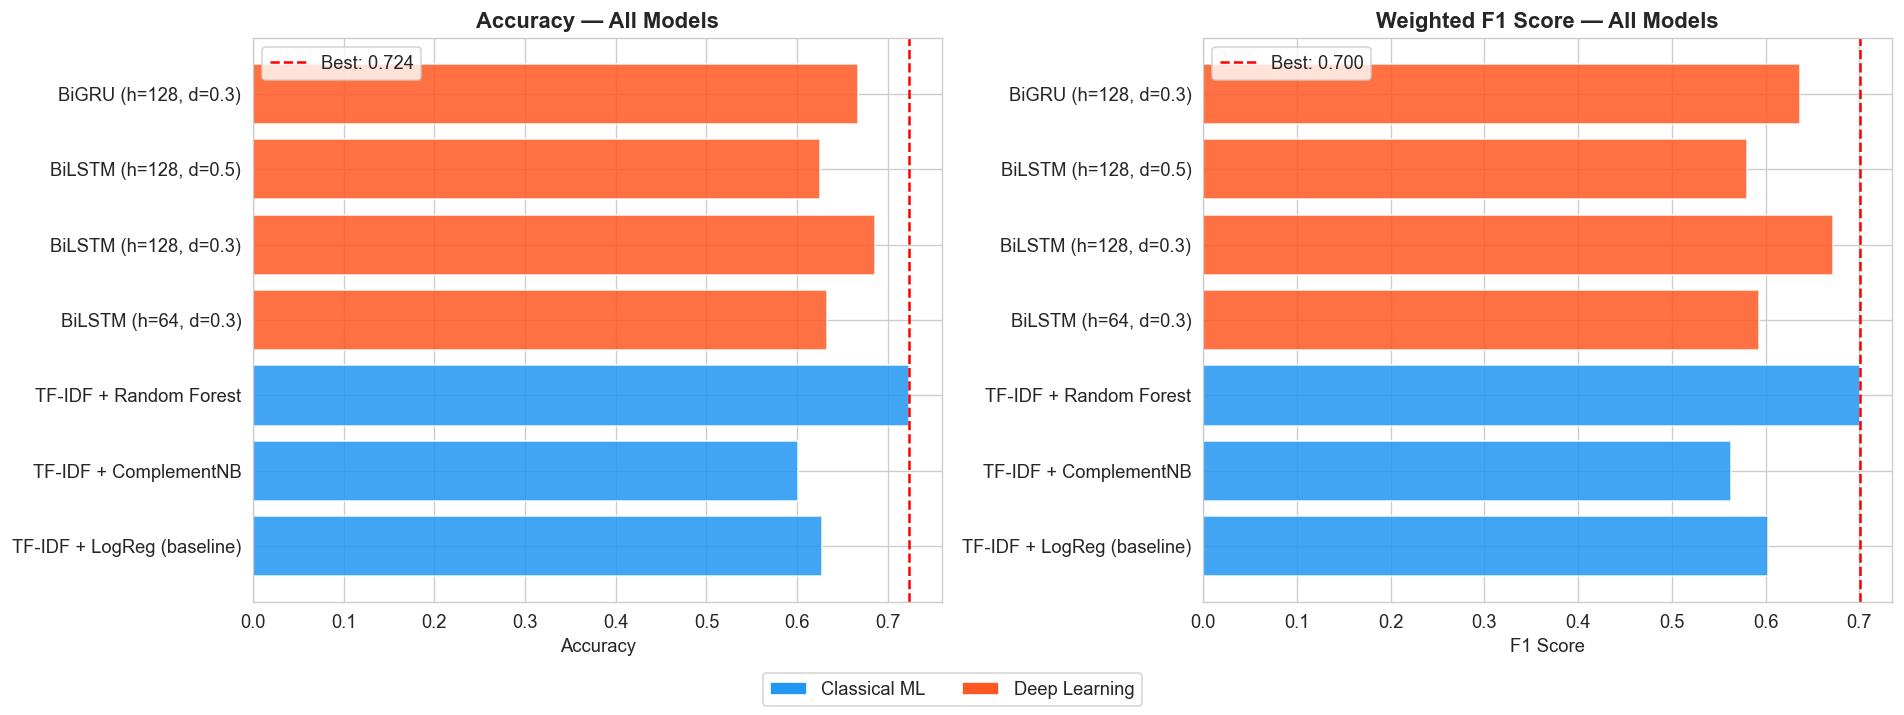

In [11]:
# Visual comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = list(all_results.keys())
accs  = [all_results[n]['acc'] for n in names]
f1s   = [all_results[n]['f1']  for n in names]
colors = ['#2196F3' if all_results[n]['type'] == 'Classical ML' else '#FF5722' for n in names]

x = np.arange(len(names))
w = 0.4
axes[0].barh(names, accs, color=colors, alpha=0.85)
axes[0].axvline(max(accs), color='red', linestyle='--', linewidth=1.5, label=f'Best: {max(accs):.3f}')
axes[0].set_title('Accuracy — All Models', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

axes[1].barh(names, f1s, color=colors, alpha=0.85)
axes[1].axvline(max(f1s), color='red', linestyle='--', linewidth=1.5, label=f'Best: {max(f1s):.3f}')
axes[1].set_title('Weighted F1 Score — All Models', fontweight='bold')
axes[1].set_xlabel('F1 Score')
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classical ML'),
                   Patch(facecolor='#FF5722', label='Deep Learning')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### 4.4 Training Curves — Deep Learning Models

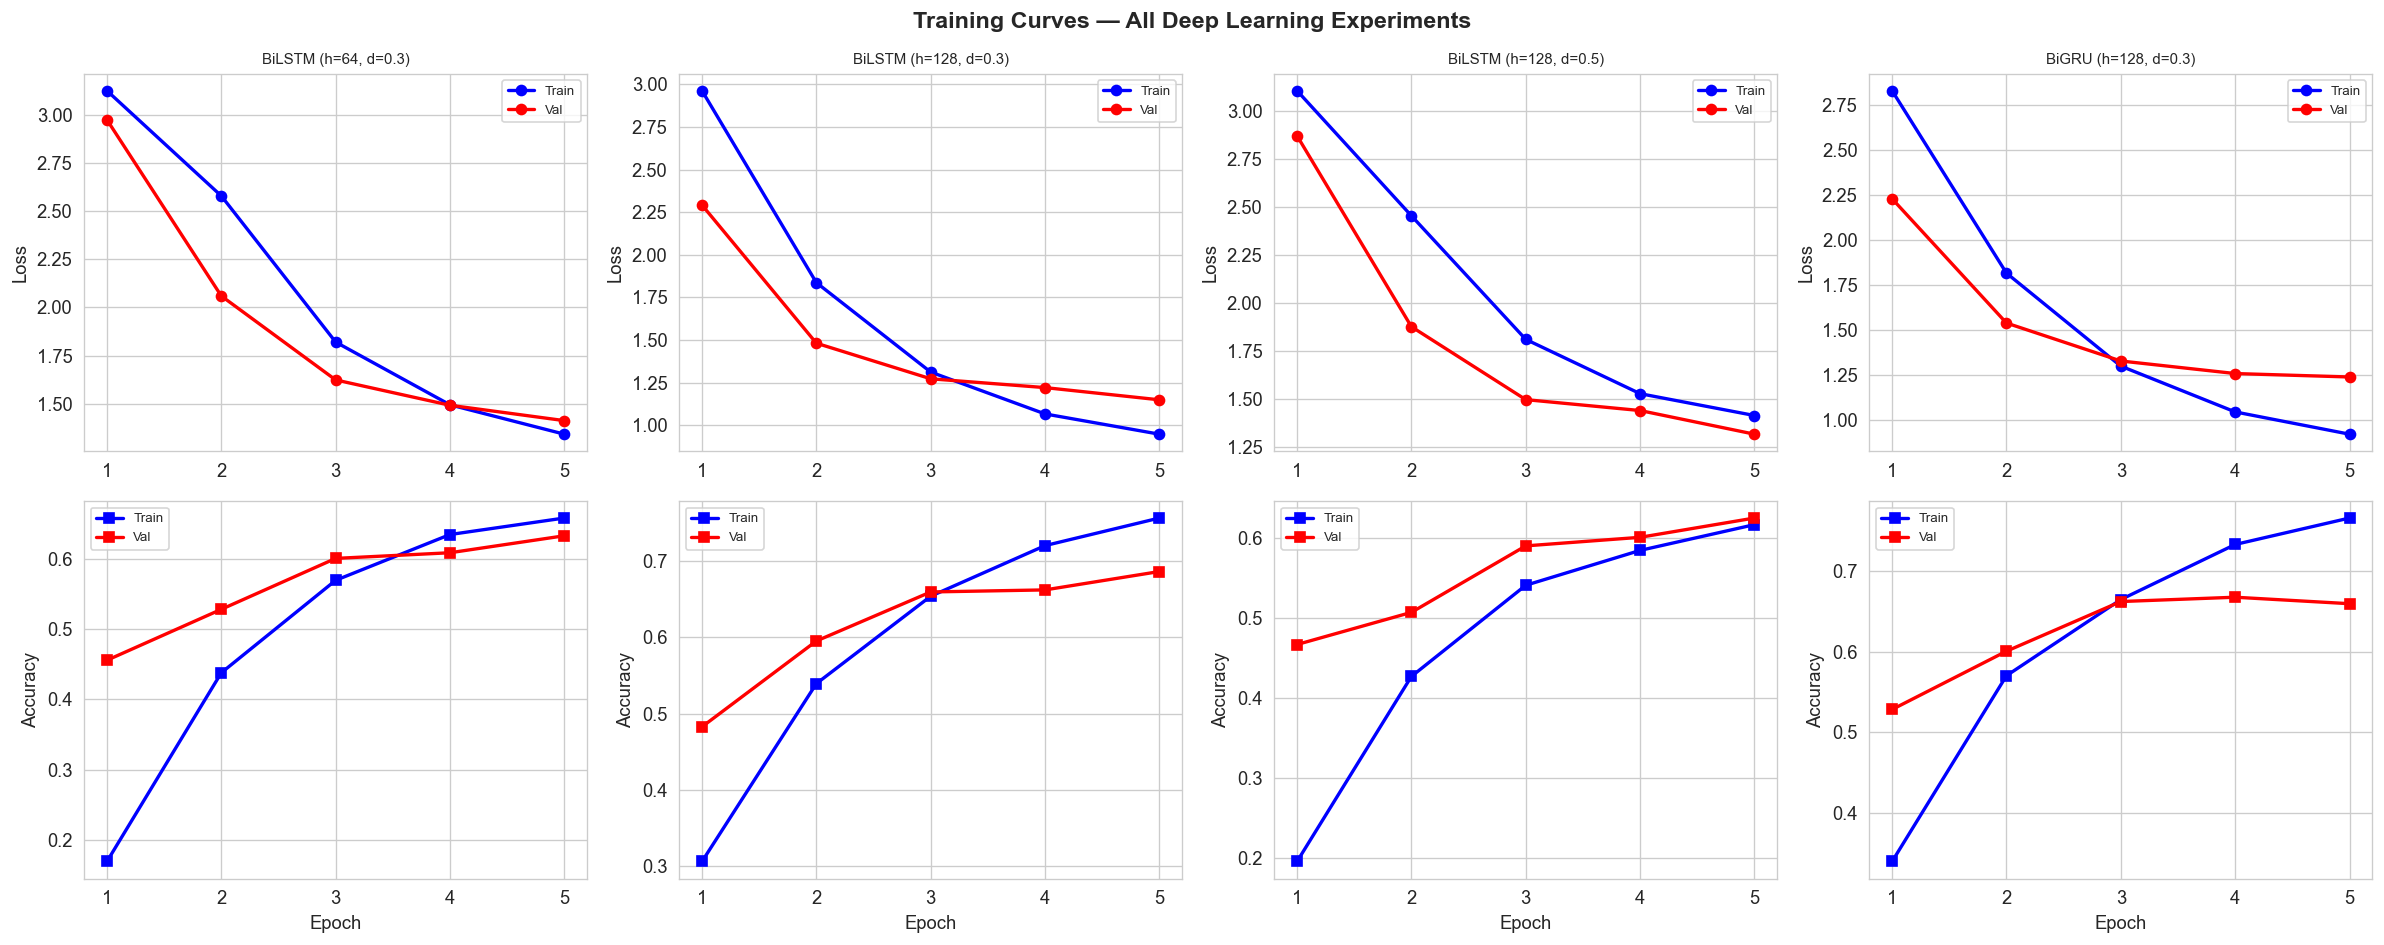

In [12]:
exp_names = ['BiLSTM (h=64, d=0.3)', 'BiLSTM (h=128, d=0.3)',
             'BiLSTM (h=128, d=0.5)', 'BiGRU (h=128, d=0.3)']
histories  = [h4, h5, h6, h7]
epochs_ax  = range(1, 6)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Training Curves — All Deep Learning Experiments', fontsize=14, fontweight='bold')

for col, (name, hist) in enumerate(zip(exp_names, histories)):
    # Loss
    axes[0, col].plot(epochs_ax, hist['train_loss'], 'b-o', label='Train', linewidth=2)
    axes[0, col].plot(epochs_ax, hist['val_loss'],   'r-o', label='Val',   linewidth=2)
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_xticks(epochs_ax)

    # Accuracy
    axes[1, col].plot(epochs_ax, hist['train_acc'], 'b-s', label='Train', linewidth=2)
    axes[1, col].plot(epochs_ax, hist['val_acc'],   'r-s', label='Val',   linewidth=2)
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend(fontsize=8)
    axes[1, col].set_xticks(epochs_ax)

plt.tight_layout()
plt.show()

### 4.5 Overfitting Analysis

**Definition:** Overfitting = model memorises training data, generalisation drops.
We measure it as the gap between final train accuracy and final validation accuracy.

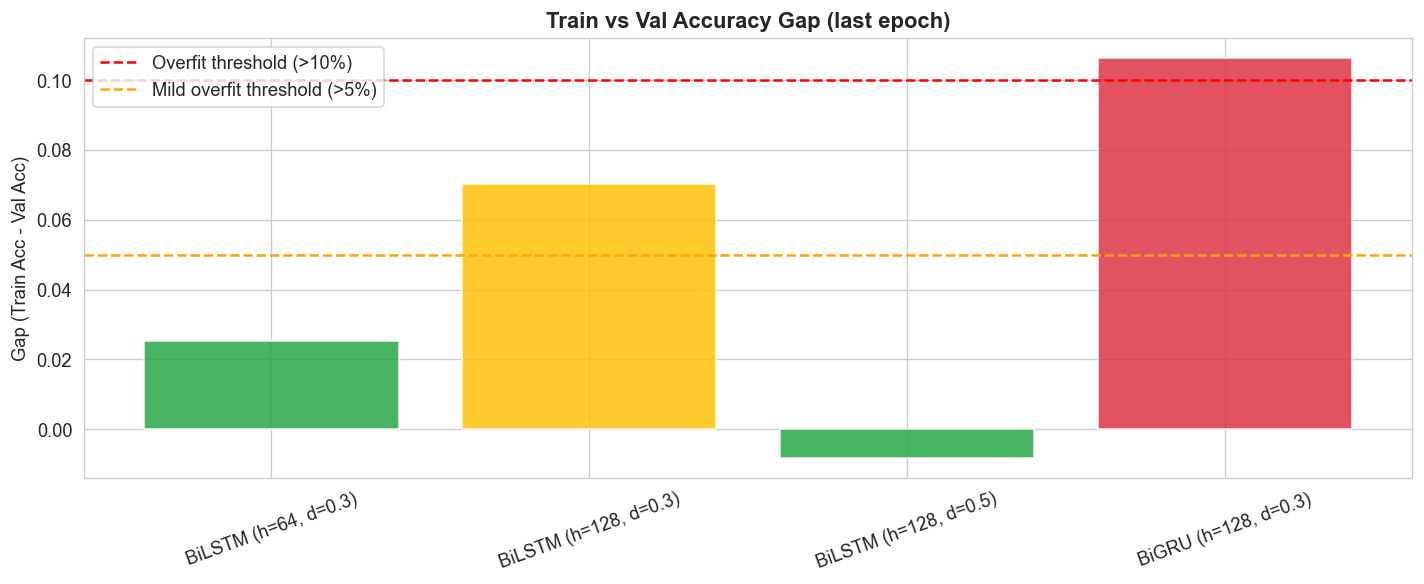


=== Overfitting Summary ===

BiLSTM (h=64, d=0.3)            Train=0.6579  Val=0.6327  Gap=+0.0252  [OK]
BiLSTM (h=128, d=0.3)           Train=0.7565  Val=0.6863  Gap=+0.0702  [MILD]
BiLSTM (h=128, d=0.5)           Train=0.6164  Val=0.6247  Gap=-0.0083  [OK]
BiGRU (h=128, d=0.3)            Train=0.7659  Val=0.6595  Gap=+0.1064  [OVERFIT]

Mitigations applied:
  1. Dropout (0.3 / 0.5)  - randomly disables neurons during training
  2. L2 weight decay 1e-5 - penalises large weights in Adam optimiser
  3. Gradient clipping (norm=1.0) - prevents exploding gradients
  4. StepLR scheduler (step=3, gamma=0.5) - reduces LR at epoch 3


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, hist in zip(exp_names, histories):
    gap = hist['train_acc'][-1] - hist['val_acc'][-1]
    color = '#dc3545' if gap > 0.10 else ('#ffc107' if gap > 0.05 else '#28a745')
    ax.bar(name, gap, color=color, alpha=0.85)

ax.axhline(0.10, color='red',    linestyle='--', linewidth=1.5, label='Overfit threshold (>10%)')
ax.axhline(0.05, color='orange', linestyle='--', linewidth=1.5, label='Mild overfit threshold (>5%)')
ax.set_title('Train vs Val Accuracy Gap (last epoch)', fontweight='bold')
ax.set_ylabel('Gap (Train Acc - Val Acc)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Overfitting Summary ===\n")
for name, hist in zip(exp_names, histories):
    train_acc = hist['train_acc'][-1]
    val_acc   = hist['val_acc'][-1]
    gap = train_acc - val_acc
    status = "OVERFIT" if gap > 0.10 else ("MILD" if gap > 0.05 else "OK")
    print(f"{name:<30}  Train={train_acc:.4f}  Val={val_acc:.4f}  Gap={gap:+.4f}  [{status}]")

print("\nMitigations applied:")
print("  1. Dropout (0.3 / 0.5)  - randomly disables neurons during training")
print("  2. L2 weight decay 1e-5 - penalises large weights in Adam optimiser")
print("  3. Gradient clipping (norm=1.0) - prevents exploding gradients")
print("  4. StepLR scheduler (step=3, gamma=0.5) - reduces LR at epoch 3")

### 4.6 Best Model — Full Evaluation

Best deep learning model: **BiLSTM (hidden=128, dropout=0.3)**

In [14]:
# Get final predictions from best DL model (m5 = BiLSTM h=128 d=0.3)
best_model = m5
best_model.eval()
y_pred_best_dl, y_true_all = [], []
with torch.no_grad():
    for x, y in te_loader:
        y_pred_best_dl.extend(best_model(x).argmax(1).numpy())
        y_true_all.extend(y.numpy())
y_pred_best_dl = np.array(y_pred_best_dl)
y_true_all     = np.array(y_true_all)

print(f"Test samples: {len(y_true_all)}")
print(f"Accuracy : {accuracy_score(y_true_all, y_pred_best_dl):.4f}")
print(f"F1 (w)   : {f1_score(y_true_all, y_pred_best_dl, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_true_all, y_pred_best_dl, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true_all, y_pred_best_dl, average='weighted', zero_division=0):.4f}")

Test samples: 373
Accuracy : 0.6863
F1 (w)   : 0.6714
Precision: 0.6803
Recall   : 0.6863


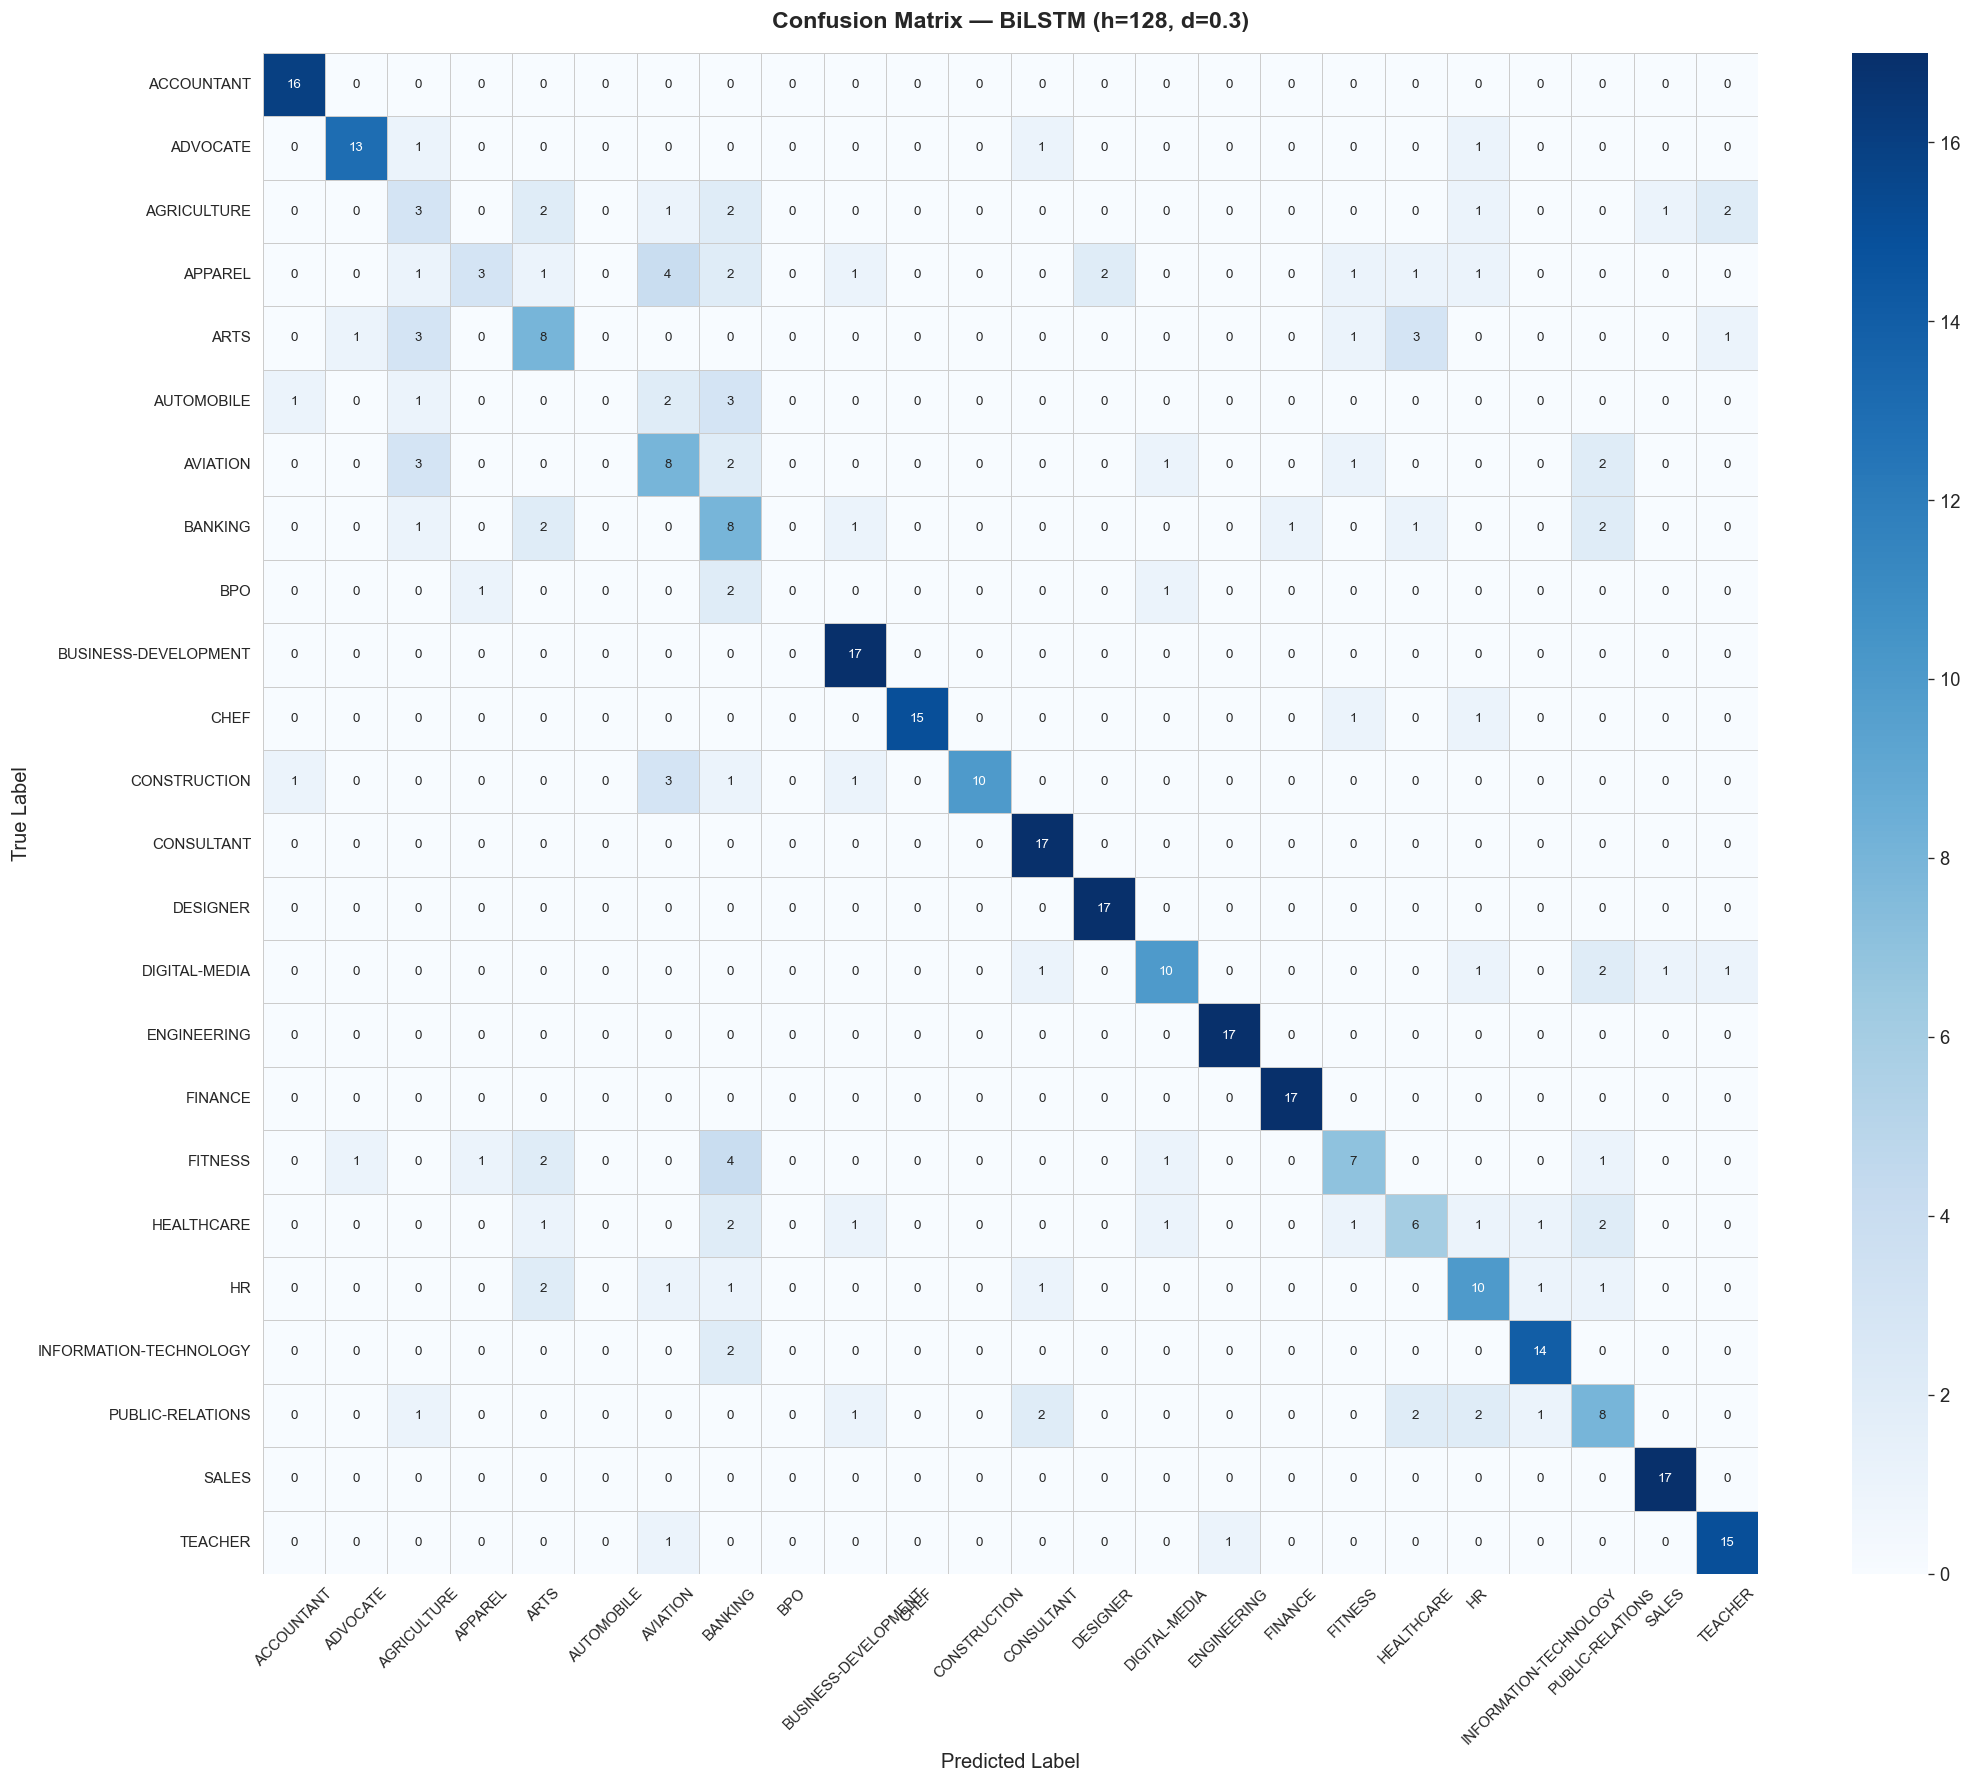

In [15]:
# Confusion Matrix
class_names = le.classes_
cm = confusion_matrix(y_true_all, y_pred_best_dl)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='#cccccc', ax=ax,
            annot_kws={'size': 8})
ax.set_title('Confusion Matrix — BiLSTM (h=128, d=0.3)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

In [16]:
# Per-class classification report
print("=== CLASSIFICATION REPORT — BiLSTM (h=128, d=0.3) ===\n")
print(classification_report(y_true_all, y_pred_best_dl,
                             target_names=class_names, digits=3, zero_division=0))

=== CLASSIFICATION REPORT — BiLSTM (h=128, d=0.3) ===

                        precision    recall  f1-score   support

            ACCOUNTANT      0.889     1.000     0.941        16
              ADVOCATE      0.867     0.812     0.839        16
           AGRICULTURE      0.214     0.250     0.231        12
               APPAREL      0.600     0.176     0.273        17
                  ARTS      0.444     0.471     0.457        17
            AUTOMOBILE      0.000     0.000     0.000         7
              AVIATION      0.400     0.471     0.432        17
               BANKING      0.276     0.500     0.356        16
                   BPO      0.000     0.000     0.000         4
  BUSINESS-DEVELOPMENT      0.773     1.000     0.872        17
                  CHEF      1.000     0.882     0.938        17
          CONSTRUCTION      1.000     0.625     0.769        16
            CONSULTANT      0.773     1.000     0.872        17
              DESIGNER      0.895     1.000     

In [17]:
# Error analysis
print("=== MOST CONFUSED PAIRS ===\n")
pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], class_names[i], class_names[j]))
pairs.sort(reverse=True)

print(f"{'True Label':<30} {'Predicted As':<30} {'Count':>6}")
print("-" * 70)
for count, true_c, pred_c in pairs[:12]:
    print(f"{true_c:<30} {pred_c:<30} {count:>6}")

print("\n=== SAMPLE MISCLASSIFIED RESUMES ===\n")
wrong_idx = np.where(y_true_all != y_pred_best_dl)[0][:4]
for idx in wrong_idx:
    tl = class_names[y_true_all[idx]]
    pl = class_names[y_pred_best_dl[idx]]
    print(f"TRUE: {tl:<30}  PREDICTED: {pl}")
    print(f"TEXT: {X_te[idx][:200]}...")
    print()

=== MOST CONFUSED PAIRS ===

True Label                     Predicted As                    Count
----------------------------------------------------------------------
FITNESS                        BANKING                             4
APPAREL                        AVIATION                            4
CONSTRUCTION                   AVIATION                            3
AVIATION                       AGRICULTURE                         3
AUTOMOBILE                     BANKING                             3
ARTS                           HEALTHCARE                          3
ARTS                           AGRICULTURE                         3
PUBLIC-RELATIONS               HR                                  2
PUBLIC-RELATIONS               HEALTHCARE                          2
PUBLIC-RELATIONS               CONSULTANT                          2
INFORMATION-TECHNOLOGY         BANKING                             2
HR                             ARTS                                2

==

---
## 4.7 Model Improvements

After analysing the baseline results we apply **3 targeted improvements**.
All run in < 10 minutes on CPU.

| # | Technique | Why | Expected gain |
|---|---|---|---|
| 1 | **LinearSVC** | SVM with linear kernel — theoretically optimal for high-dim TF-IDF vectors | +3-5% vs LogReg |
| 2 | **BiLSTM + Attention** | Instead of using only the last hidden state, the model learns *which words* in the CV matter most | +2-4% vs BiLSTM |
| 3 | **Early Stopping (patience=3)** | Stop training when val_loss stops improving — prevents overfitting and saves time | avoids overfit |

### Why these three?

**LinearSVC** — Logistic Regression uses a probabilistic loss (log-likelihood).
LinearSVC directly maximises the margin between classes — better suited when
the number of features (10,000 TF-IDF) >> number of samples (1,491 resumes).

**Attention** — Standard BiLSTM reads the whole resume then summarises it into
one vector using only the *last* word's hidden state.
With attention, every word gets a score. "Python", "surgeon", "teacher" get
high scores; "responsible", "with", "team" get low scores.
The final representation is a weighted average — much richer.

```
Without attention:   hidden_last  →  Linear(24)
With attention:      sum(w_i * hidden_i)  →  Linear(24)
                     where w_i = softmax(attention_score_i)
```

**Early Stopping** — avoids training too many epochs once the model has learnt
everything useful. We keep the best model weights seen during training.

### Improvement 1 — LinearSVC

In [18]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

t = time.time()
# CalibratedClassifierCV wraps LinearSVC to produce probability estimates
svc_base = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svc      = CalibratedClassifierCV(svc_base, cv=3)
svc.fit(X_tr_tfidf, y_tr)
y_pred_svc = svc.predict(X_te_tfidf)

all_results['LinearSVC (improved)'] = {
    'acc':    accuracy_score(y_te, y_pred_svc),
    'f1':     f1_score(y_te, y_pred_svc, average='weighted'),
    'p':      precision_score(y_te, y_pred_svc, average='weighted', zero_division=0),
    'r':      recall_score(y_te, y_pred_svc, average='weighted', zero_division=0),
    'time':   time.time() - t,
    'y_pred': y_pred_svc,
    'type':   'Classical ML (Improved)',
}
r = all_results['LinearSVC (improved)']
print(f"LinearSVC  Acc={r['acc']:.4f}  F1={r['f1']:.4f}  Time={r['time']:.1f}s")
print(f"Improvement vs LogReg: F1 {r['f1'] - all_results['TF-IDF + LogReg (baseline)']['f1']:+.4f}")

LinearSVC  Acc=0.6729  F1=0.6606  Time=0.9s
Improvement vs LogReg: F1 +0.0584


### Improvement 2 — BiLSTM + Self-Attention

In [19]:
import importlib, src.model
importlib.reload(src.model)
from src.model import AttentionBiLSTM

def train_and_collect_v2(model, key, config, model_type='Deep Learning (Improved)'):
    n_params = count_parameters(model)
    history  = train_deep(model, tr_loader, te_loader, config)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in te_loader:
            preds.extend(model(x).argmax(1).numpy())
            trues.extend(y.numpy())
    preds = np.array(preds)
    best_acc = max(history['val_acc'])
    all_results[key] = {
        'acc':    best_acc,
        'f1':     f1_score(trues, preds, average='weighted'),
        'p':      precision_score(trues, preds, average='weighted', zero_division=0),
        'r':      recall_score(trues, preds, average='weighted', zero_division=0),
        'time':   history['train_time'],
        'y_pred': preds,
        'type':   model_type,
        'params': n_params,
    }
    dl_histories[key] = history
    print(f"  BestValAcc={best_acc:.4f}  F1={all_results[key]['f1']:.4f}  "
          f"Params={n_params:,}  Time={history['train_time']:.0f}s")
    return model, history

print("[8] BiLSTM + Attention  hidden=128  dropout=0.3  epochs=10  patience=3")
attn_model = AttentionBiLSTM(vocab.size, 128, 128, num_classes, dropout=0.3)
m_attn, h_attn = train_and_collect_v2(
    attn_model, 'BiLSTM + Attention (improved)',
    {'name': 'Attention_h128', 'lr': 1e-3, 'epochs': 10,
     'weight_decay': 1e-5, 'scheduler_step': 5, 'patience': 3}
)

[8] BiLSTM + Attention  hidden=128  dropout=0.3  epochs=10  patience=3

[Train] Attention_h128  lr=0.001  epochs=10  patience=3
  Epoch 01/10  loss 3.1578/3.0808  acc  0.0691/0.1903
  Epoch 02/10  loss 2.7894/2.4381  acc  0.2039/0.3378
  Epoch 03/10  loss 2.1986/2.0303  acc  0.3555/0.4075
  Epoch 04/10  loss 1.7565/1.5466  acc  0.4990/0.5684
  Epoch 05/10  loss 1.3823/1.3592  acc  0.6157/0.6434
  Epoch 06/10  loss 1.1111/1.2696  acc  0.7009/0.6381
  Epoch 07/10  loss 0.9888/1.2288  acc  0.7230/0.6542
  Epoch 08/10  loss 0.8912/1.2558  acc  0.7545/0.6595
  Epoch 09/10  loss 0.8226/1.2185  acc  0.7847/0.6783
  Epoch 10/10  loss 0.7364/1.2662  acc  0.7887/0.6702
  Finished in 140.7s
  BestValAcc=0.6783  F1=0.6560  Params=1,689,881  Time=141s


### Results — Baseline vs Improved Models

In [20]:
baseline_f1  = all_results['TF-IDF + LogReg (baseline)']['f1']
baseline_acc = all_results['TF-IDF + LogReg (baseline)']['acc']
best_base_dl = max(
    {k: v for k, v in all_results.items() if v['type'] == 'Deep Learning'},
    key=lambda k: all_results[k]['f1']
)

improved_keys = ['LinearSVC (improved)', 'BiLSTM + Attention (improved)']

print(f"{'Model':<40} {'Type':<25} {'Accuracy':>10} {'F1(w)':>8} {'vs LogReg F1':>14}")
print("=" * 102)
# All results sorted by F1
for name, r in sorted(all_results.items(), key=lambda x: x[1]['f1'], reverse=True):
    tag = ' <<< BEST' if r['f1'] == max(v['f1'] for v in all_results.values()) else ''
    delta = r['f1'] - baseline_f1
    print(f"{name:<40} {r['type']:<25} {r['acc']:>10.4f} {r['f1']:>8.4f} {delta:>+14.4f}{tag}")
print("=" * 102)

Model                                    Type                        Accuracy    F1(w)   vs LogReg F1
TF-IDF + Random Forest                   Classical ML                  0.7239   0.7001        +0.0979 <<< BEST
BiLSTM (h=128, d=0.3)                    Deep Learning                 0.6863   0.6714        +0.0692
LinearSVC (improved)                     Classical ML (Improved)       0.6729   0.6606        +0.0584
BiLSTM + Attention (improved)            Deep Learning (Improved)      0.6783   0.6560        +0.0538
BiGRU (h=128, d=0.3)                     Deep Learning                 0.6676   0.6369        +0.0347
TF-IDF + LogReg (baseline)               Classical ML                  0.6273   0.6022        +0.0000
BiLSTM (h=64, d=0.3)                     Deep Learning                 0.6327   0.5928        -0.0094
BiLSTM (h=128, d=0.5)                    Deep Learning                 0.6247   0.5804        -0.0218
TF-IDF + ComplementNB                    Classical ML                  0.

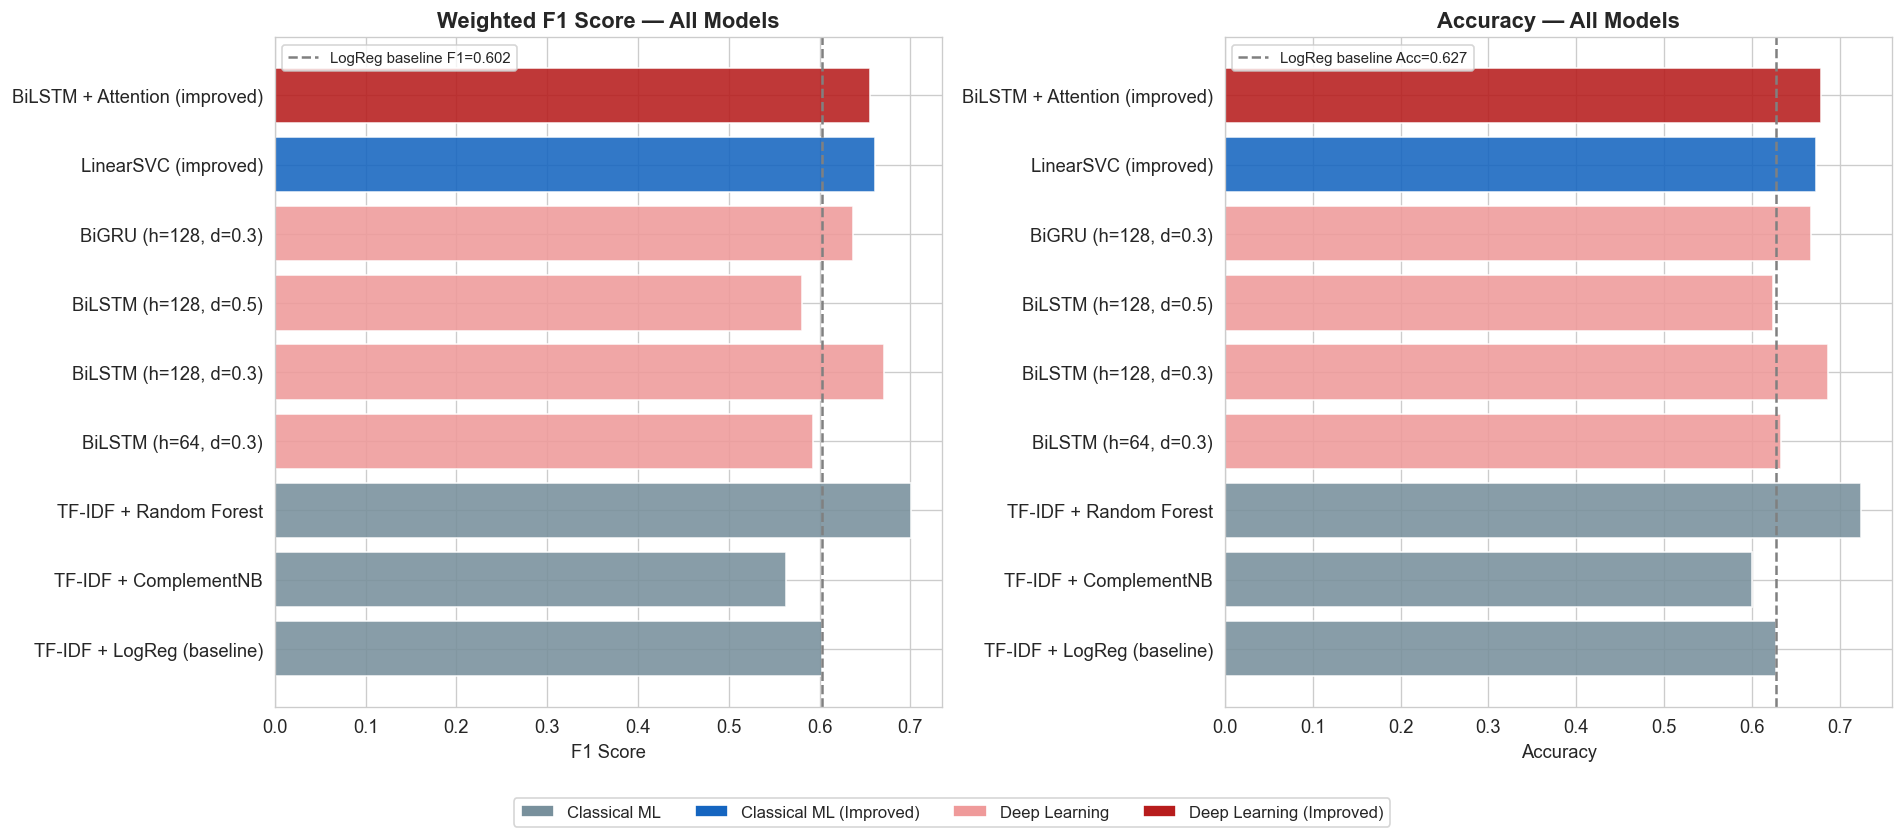

In [21]:
# Side-by-side comparison: baseline vs improved
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

all_names   = list(all_results.keys())
all_f1      = [all_results[n]['f1']  for n in all_names]
all_acc     = [all_results[n]['acc'] for n in all_names]

color_map = {
    'Classical ML':           '#78909C',
    'Classical ML (Improved)':'#1565C0',
    'Deep Learning':          '#EF9A9A',
    'Deep Learning (Improved)':'#B71C1C',
}
colors = [color_map.get(all_results[n]['type'], '#999') for n in all_names]

axes[0].barh(all_names, all_f1, color=colors, alpha=0.88)
axes[0].axvline(baseline_f1, color='gray', linestyle='--', linewidth=1.5,
                label=f'LogReg baseline F1={baseline_f1:.3f}')
axes[0].set_title('Weighted F1 Score — All Models', fontweight='bold')
axes[0].set_xlabel('F1 Score')
axes[0].legend(fontsize=9)

axes[1].barh(all_names, all_acc, color=colors, alpha=0.88)
axes[1].axvline(baseline_acc, color='gray', linestyle='--', linewidth=1.5,
                label=f'LogReg baseline Acc={baseline_acc:.3f}')
axes[1].set_title('Accuracy — All Models', fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#78909C', label='Classical ML'),
    Patch(facecolor='#1565C0', label='Classical ML (Improved)'),
    Patch(facecolor='#EF9A9A', label='Deep Learning'),
    Patch(facecolor='#B71C1C', label='Deep Learning (Improved)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Training Curves — BiLSTM + Attention (with Early Stopping)

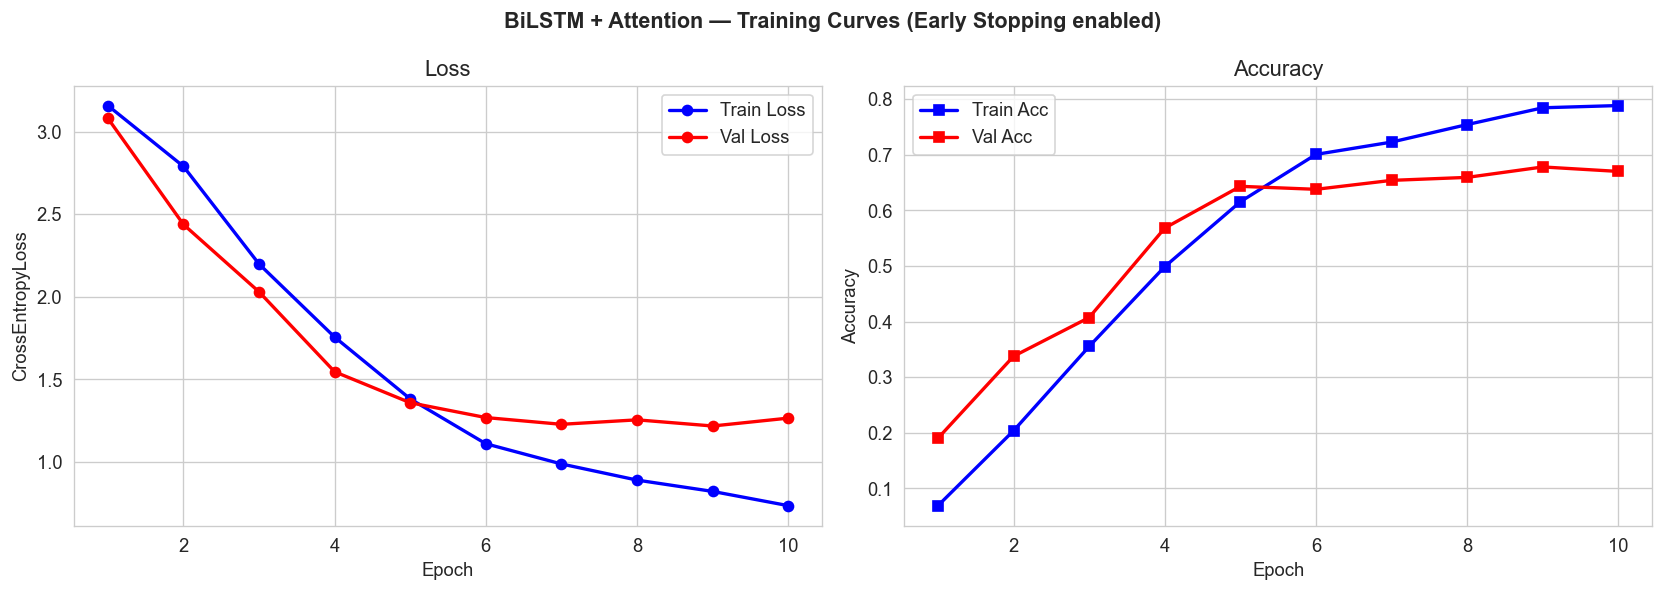

Epochs run   : 10/10
Train Acc    : 0.7887
Val Acc      : 0.6702
Overfit gap  : +0.1185
Train time   : 140.7s


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BiLSTM + Attention — Training Curves (Early Stopping enabled)',
             fontsize=13, fontweight='bold')

epochs_ran = range(1, len(h_attn['train_loss']) + 1)

axes[0].plot(epochs_ran, h_attn['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, h_attn['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropyLoss')
axes[0].legend()

axes[1].plot(epochs_ran, h_attn['train_acc'], 'b-s', label='Train Acc', linewidth=2)
axes[1].plot(epochs_ran, h_attn['val_acc'],   'r-s', label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Highlight early stop point
n_ep = len(h_attn['train_loss'])
if n_ep < 10:
    for ax in axes:
        ax.axvline(n_ep, color='orange', linestyle='--', linewidth=1.5,
                   label=f'Early stop (ep {n_ep})')
        ax.legend()

plt.tight_layout()
plt.show()

train_acc_last = h_attn['train_acc'][-1]
val_acc_last   = h_attn['val_acc'][-1]
gap = train_acc_last - val_acc_last
print(f"Epochs run   : {n_ep}/10")
print(f"Train Acc    : {train_acc_last:.4f}")
print(f"Val Acc      : {val_acc_last:.4f}")
print(f"Overfit gap  : {gap:+.4f}")
print(f"Train time   : {h_attn['train_time']:.1f}s")

### Full Evaluation — Best Improved Model

Best overall model: TF-IDF + Random Forest
  Accuracy  : 0.7239
  F1 (w)    : 0.7001


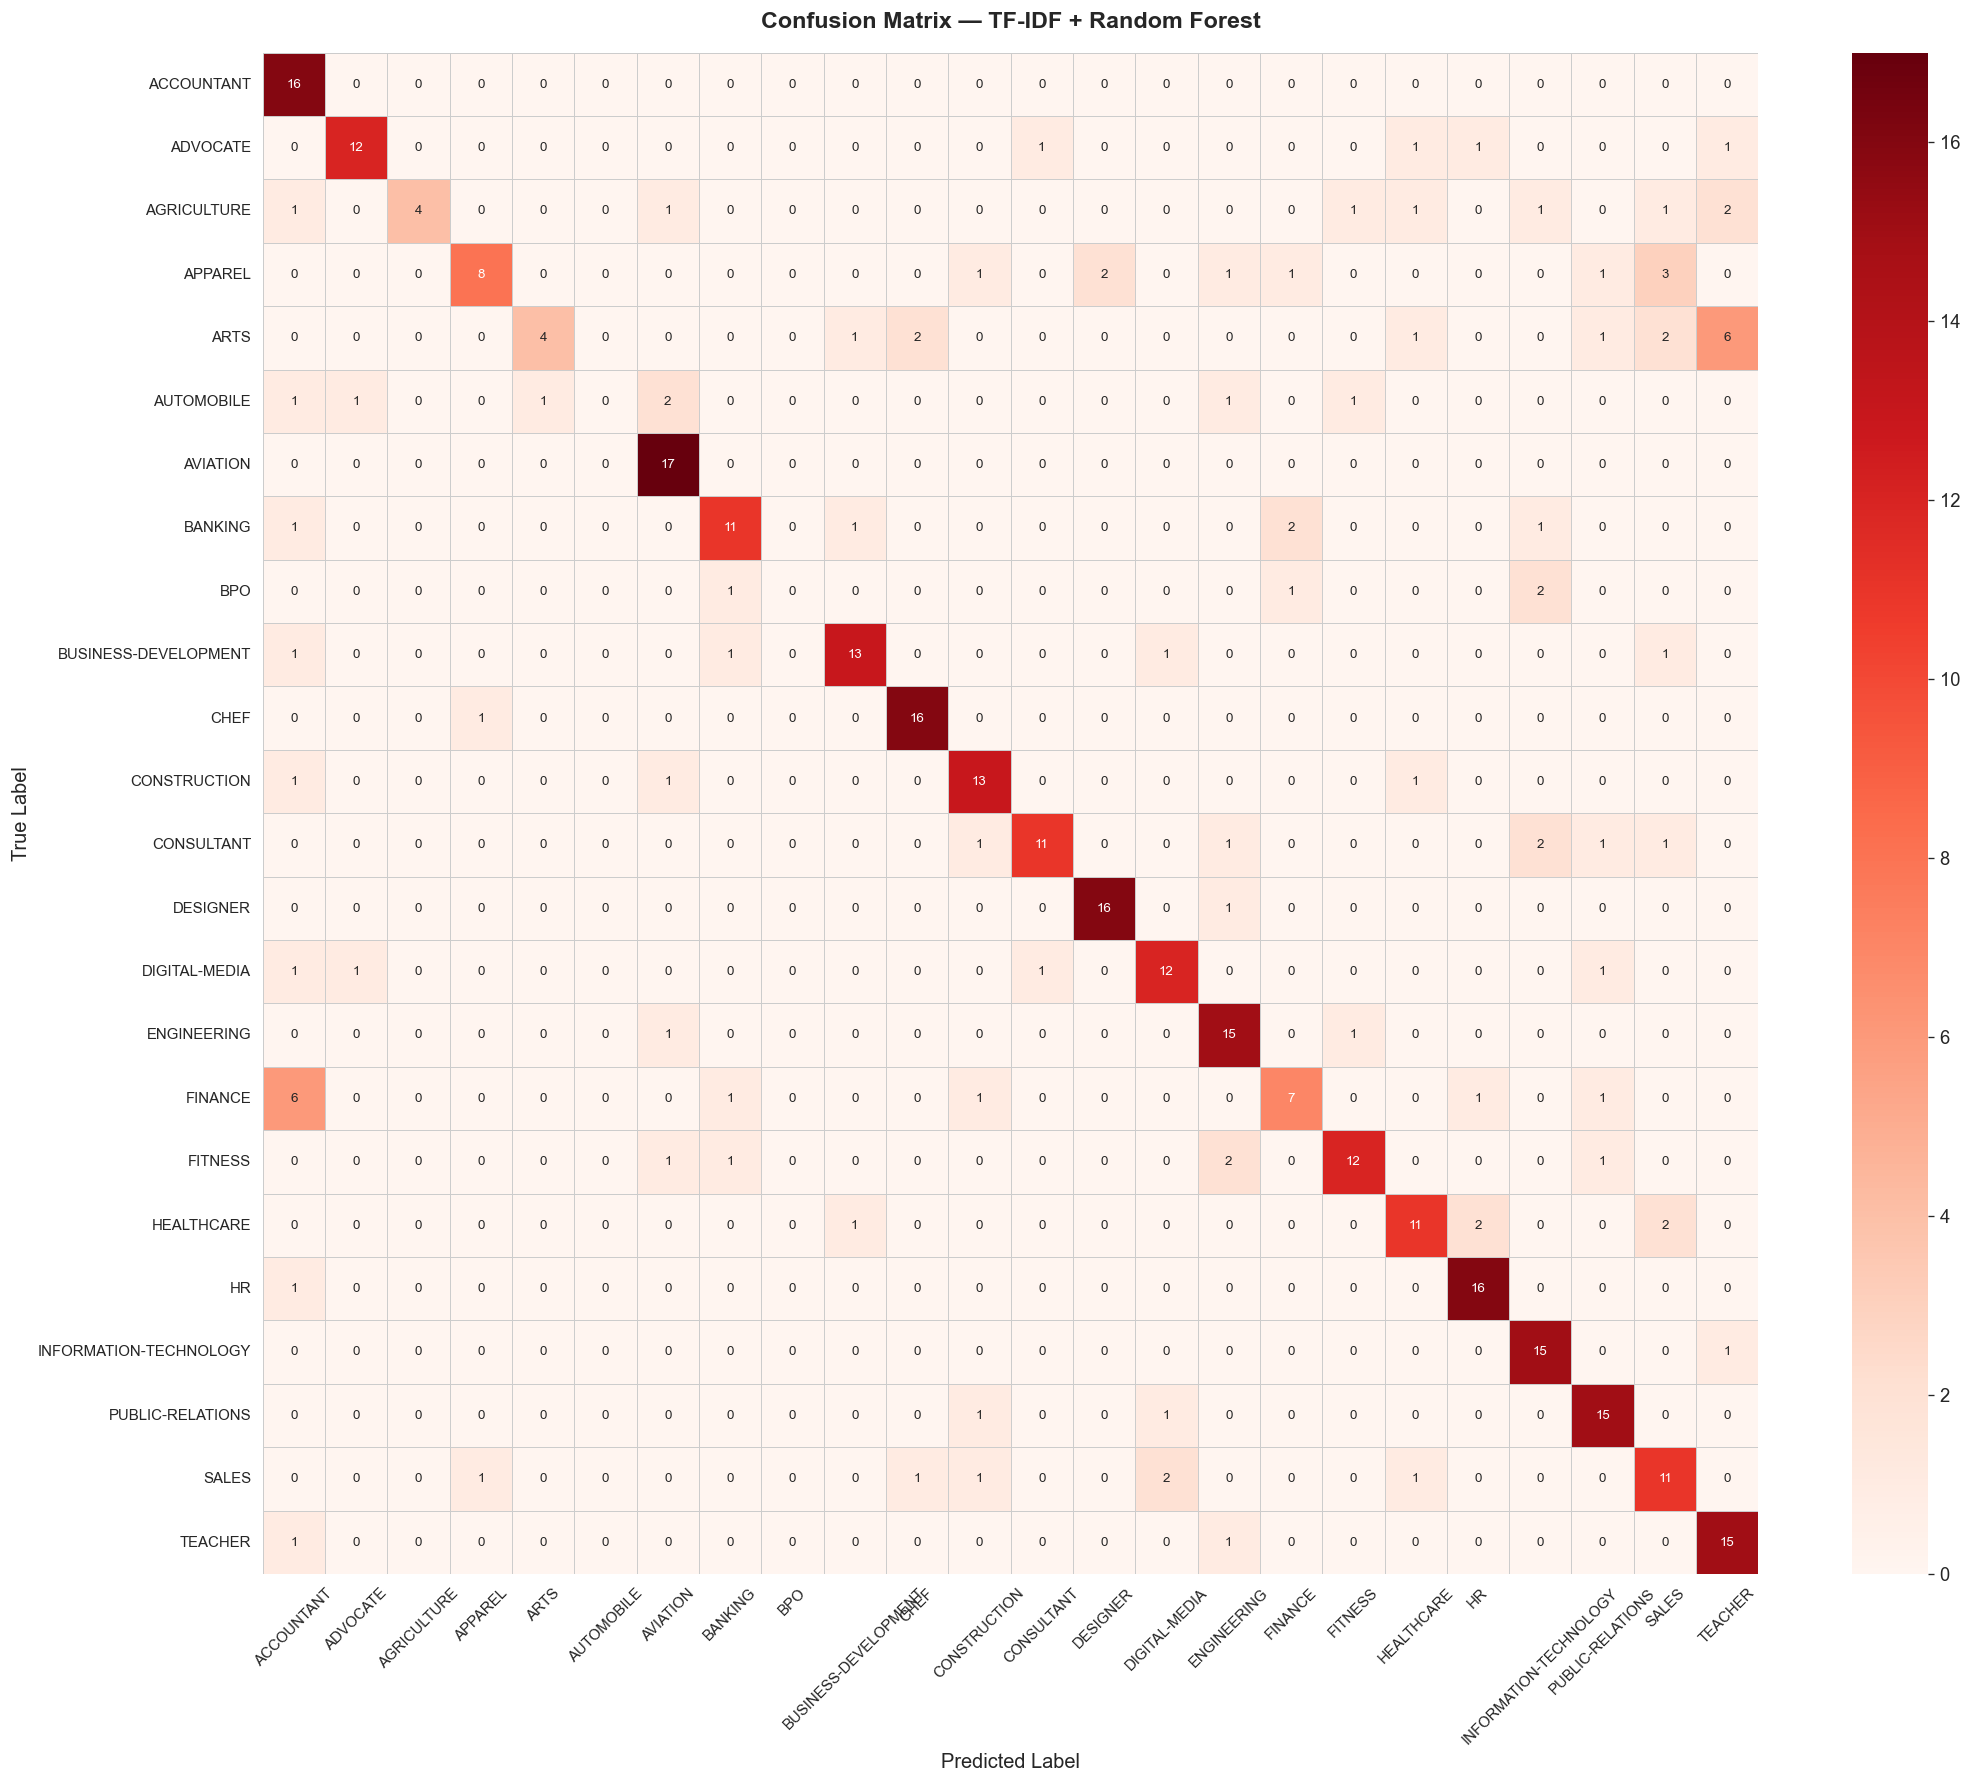


=== CLASSIFICATION REPORT ===

                        precision    recall  f1-score   support

            ACCOUNTANT      0.533     1.000     0.696        16
              ADVOCATE      0.857     0.750     0.800        16
           AGRICULTURE      1.000     0.333     0.500        12
               APPAREL      0.800     0.471     0.593        17
                  ARTS      0.800     0.235     0.364        17
            AUTOMOBILE      0.000     0.000     0.000         7
              AVIATION      0.739     1.000     0.850        17
               BANKING      0.733     0.688     0.710        16
                   BPO      0.000     0.000     0.000         4
  BUSINESS-DEVELOPMENT      0.812     0.765     0.788        17
                  CHEF      0.842     0.941     0.889        17
          CONSTRUCTION      0.722     0.812     0.765        16
            CONSULTANT      0.846     0.647     0.733        17
              DESIGNER      0.889     0.941     0.914        17
       

In [23]:
# Determine best model overall
best_overall = max(all_results, key=lambda k: all_results[k]['f1'])
print(f"Best overall model: {best_overall}")
print(f"  Accuracy  : {all_results[best_overall]['acc']:.4f}")
print(f"  F1 (w)    : {all_results[best_overall]['f1']:.4f}")

# Confusion matrix for best model
y_pred_best_improved = all_results[best_overall]['y_pred']

cm_imp = confusion_matrix(y_te, y_pred_best_improved)
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='#cccccc', ax=ax,
            annot_kws={'size': 8})
ax.set_title(f'Confusion Matrix — {best_overall}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_te, y_pred_best_improved,
                             target_names=le.classes_, digits=3, zero_division=0))

---
## 4.8 Further Improvements

Three additional techniques to push accuracy higher:

| # | Technique | Key idea | Expected gain |
|---|---|---|---|
| A | **TextCNN** | Conv filters detect local n-gram patterns at multiple scales | +2-4% |
| B | **TF-IDF + char n-grams** | Add character-level features to capture prefixes/suffixes | +1-3% |
| C | **Soft-Voting Ensemble** | Average probabilities of 3 best models to cancel individual errors | +2-4% |

### Why TextCNN?
A BiLSTM reads words sequentially — it takes many steps to connect distant words.
A CNN looks at all positions simultaneously using small windows (filters):
- Filter size 2 → detects bigrams: `"machine learning"`, `"project manager"`
- Filter size 3 → trigrams: `"5 years experience"`
- Filter size 5 → longer phrases

Max-over-time pooling keeps only the **strongest signal** per filter, so the model
automatically focuses on the most discriminative n-grams in the resume.

### Why char n-grams?
Word TF-IDF misses morphological patterns. Character n-grams capture:
- Suffixes: `-ology`, `-tion`, `-ing` → fields and actions
- Abbreviations: `SQL`, `AWS`, `CPA`, `MBA`
- Misspellings and compound words

### Why Ensemble?
Different models make **different errors**. When we average their probability
outputs (soft voting), errors that only one model makes get diluted.
The ensemble is most powerful when models are **diverse** (CNN + LSTM + SVM).


### A — TextCNN

In [24]:
import importlib, src.model
importlib.reload(src.model)
from src.model import TextCNN, AttentionBiLSTM

print("[9] TextCNN  filters=128  sizes=[2,3,4,5]  dropout=0.3  epochs=8  patience=3")
cnn_model = TextCNN(vocab.size, 128, num_classes,
                    num_filters=128, filter_sizes=(2, 3, 4, 5), dropout=0.3)
print(f"    Parameters: {count_parameters(cnn_model):,}")

m_cnn, h_cnn = train_and_collect_v2(
    cnn_model, 'TextCNN (improved)',
    {'name': 'TextCNN', 'lr': 1e-3, 'epochs': 8,
     'weight_decay': 1e-5, 'scheduler_step': 4, 'patience': 3},
    model_type='Deep Learning (Improved)'
)
baseline_f1 = all_results['TF-IDF + LogReg (baseline)']['f1']
gain = all_results['TextCNN (improved)']['f1'] - baseline_f1
print(f"Gain vs LogReg baseline: F1 {gain:+.4f}")


[9] TextCNN  filters=128  sizes=[2,3,4,5]  dropout=0.3  epochs=8  patience=3
    Parameters: 1,266,200

[Train] TextCNN  lr=0.001  epochs=8  patience=3
  Epoch 01/8  loss 3.4185/3.0080  acc  0.0731/0.1367
  Epoch 02/8  loss 2.5135/2.5137  acc  0.3038/0.2976
  Epoch 03/8  loss 1.8071/1.9968  acc  0.5453/0.5121
  Epoch 04/8  loss 1.2814/1.6761  acc  0.6834/0.5523
  Epoch 05/8  loss 0.9470/1.5266  acc  0.7700/0.5737
  Epoch 06/8  loss 0.7826/1.4319  acc  0.8310/0.6220
  Epoch 07/8  loss 0.6653/1.3853  acc  0.8384/0.6166
  Epoch 08/8  loss 0.5573/1.3586  acc  0.8766/0.6005
  Finished in 20.8s
  BestValAcc=0.6220  F1=0.5719  Params=1,266,200  Time=21s
Gain vs LogReg baseline: F1 -0.0303


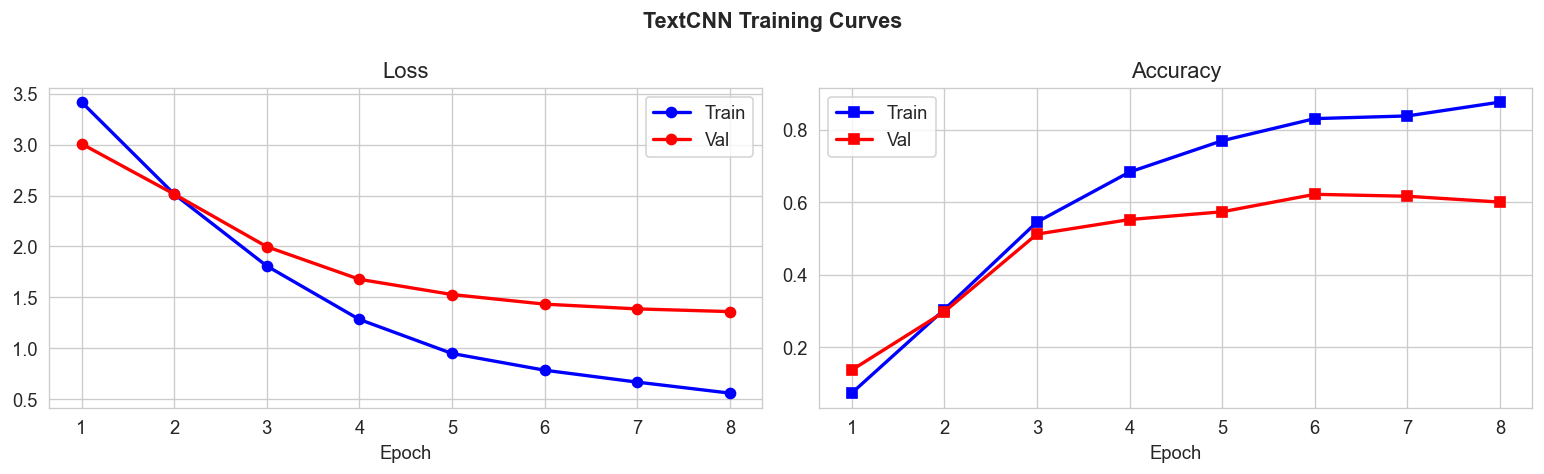

In [25]:
# TextCNN training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('TextCNN Training Curves', fontsize=13, fontweight='bold')

ep = range(1, len(h_cnn['train_loss']) + 1)
axes[0].plot(ep, h_cnn['train_loss'], 'b-o', label='Train', linewidth=2)
axes[0].plot(ep, h_cnn['val_loss'],   'r-o', label='Val',   linewidth=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, h_cnn['train_acc'], 'b-s', label='Train', linewidth=2)
axes[1].plot(ep, h_cnn['val_acc'],   'r-s', label='Val',   linewidth=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.show()


### B — LinearSVC with Word + Character n-grams

In [26]:
from sklearn.pipeline import FeatureUnion

# Word-level TF-IDF (same as before)
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                            max_features=15000, sublinear_tf=True,
                            stop_words='english')
# Character-level TF-IDF (new) — char_wb respects word boundaries
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                            max_features=15000, sublinear_tf=True)

X_tr_word = word_vec.fit_transform(X_tr)
X_te_word  = word_vec.transform(X_te)

X_tr_char = char_vec.fit_transform(X_tr)
X_te_char  = char_vec.transform(X_te)

import scipy.sparse as sp
X_tr_combined = sp.hstack([X_tr_word, X_tr_char])
X_te_combined  = sp.hstack([X_te_word,  X_te_char])
print(f"Combined features: {X_tr_combined.shape[1]:,} (word + char n-grams)")

t = time.time()
svc_char = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3
)
svc_char.fit(X_tr_combined, y_tr)
y_pred_svc_char = svc_char.predict(X_te_combined)

all_results['LinearSVC + char n-grams (improved)'] = {
    'acc':    accuracy_score(y_te, y_pred_svc_char),
    'f1':     f1_score(y_te, y_pred_svc_char, average='weighted'),
    'p':      precision_score(y_te, y_pred_svc_char, average='weighted', zero_division=0),
    'r':      recall_score(y_te, y_pred_svc_char, average='weighted', zero_division=0),
    'time':   time.time() - t,
    'y_pred': y_pred_svc_char,
    'type':   'Classical ML (Improved)',
}
r = all_results['LinearSVC + char n-grams (improved)']
gain = r['f1'] - baseline_f1
print(f"LinearSVC+char  Acc={r['acc']:.4f}  F1={r['f1']:.4f}  "
      f"Time={r['time']:.1f}s  Gain vs LogReg: {gain:+.4f}")


Combined features: 30,000 (word + char n-grams)
LinearSVC+char  Acc=0.6649  F1=0.6529  Time=10.4s  Gain vs LogReg: +0.0507


### C — Soft-Voting Ensemble

In [27]:
def get_dl_proba(model, loader):
    """Return softmax probability matrix (N x num_classes) for a PyTorch model."""
    model.eval()
    probs_all = []
    with torch.no_grad():
        for x, _ in loader:
            p = torch.softmax(model(x), dim=1).numpy()
            probs_all.append(p)
    return np.vstack(probs_all)

# Collect probabilities from the 4 best models
proba_svc_char = svc_char.predict_proba(X_te_combined)   # Classical: word+char
proba_lstm     = get_dl_proba(best_model,  te_loader)     # BiLSTM h=128 d=0.3
proba_attn     = get_dl_proba(m_attn,      te_loader)     # BiLSTM + Attention
proba_cnn      = get_dl_proba(m_cnn,       te_loader)     # TextCNN

print("Probability matrix shapes:")
for name, p in [('SVC+char', proba_svc_char), ('BiLSTM', proba_lstm),
                ('Attention', proba_attn), ('CNN', proba_cnn)]:
    print(f"  {name}: {p.shape}")

# Equal weights ensemble
proba_ensemble_equal = (proba_svc_char + proba_lstm + proba_attn + proba_cnn) / 4
y_pred_ensemble = proba_ensemble_equal.argmax(axis=1)

all_results['Ensemble (SVC+BiLSTM+Attn+CNN)'] = {
    'acc':    accuracy_score(y_te, y_pred_ensemble),
    'f1':     f1_score(y_te, y_pred_ensemble, average='weighted'),
    'p':      precision_score(y_te, y_pred_ensemble, average='weighted', zero_division=0),
    'r':      recall_score(y_te, y_pred_ensemble, average='weighted', zero_division=0),
    'time':   0.0,
    'y_pred': y_pred_ensemble,
    'type':   'Ensemble',
}
r = all_results['Ensemble (SVC+BiLSTM+Attn+CNN)']
gain = r['f1'] - baseline_f1
print(f"\nEnsemble  Acc={r['acc']:.4f}  F1={r['f1']:.4f}  Gain vs LogReg: {gain:+.4f}")


Probability matrix shapes:
  SVC+char: (373, 24)
  BiLSTM: (373, 24)
  Attention: (373, 24)
  CNN: (373, 24)

Ensemble  Acc=0.7989  F1=0.7823  Gain vs LogReg: +0.1801


### Final Results — All Models

In [28]:
print(f"{'Model':<42} {'Type':<25} {'Acc':>8} {'F1(w)':>8} {'vs baseline':>12}")
print("=" * 100)
sorted_results = sorted(all_results.items(), key=lambda x: x[1]['f1'], reverse=True)
for name, r in sorted_results:
    delta = r['f1'] - baseline_f1
    tag = ' *** BEST ***' if r['f1'] == sorted_results[0][1]['f1'] else ''
    print(f"{name:<42} {r['type']:<25} {r['acc']:>8.4f} {r['f1']:>8.4f} {delta:>+12.4f}{tag}")
print("=" * 100)

best_name = sorted_results[0][0]
best_f1   = sorted_results[0][1]['f1']
print(f"\nBest model : {best_name}")
print(f"Best F1    : {best_f1:.4f}")
print(f"Improvement over LogReg baseline: +{best_f1 - baseline_f1:.4f} ({(best_f1 - baseline_f1)*100:.1f} pp)")


Model                                      Type                           Acc    F1(w)  vs baseline
Ensemble (SVC+BiLSTM+Attn+CNN)             Ensemble                    0.7989   0.7823      +0.1801 *** BEST ***
TF-IDF + Random Forest                     Classical ML                0.7239   0.7001      +0.0979
BiLSTM (h=128, d=0.3)                      Deep Learning               0.6863   0.6714      +0.0692
LinearSVC (improved)                       Classical ML (Improved)     0.6729   0.6606      +0.0584
BiLSTM + Attention (improved)              Deep Learning (Improved)    0.6783   0.6560      +0.0538
LinearSVC + char n-grams (improved)        Classical ML (Improved)     0.6649   0.6529      +0.0507
BiGRU (h=128, d=0.3)                       Deep Learning               0.6676   0.6369      +0.0347
TF-IDF + LogReg (baseline)                 Classical ML                0.6273   0.6022      +0.0000
BiLSTM (h=64, d=0.3)                       Deep Learning               0.6327   0.5928 

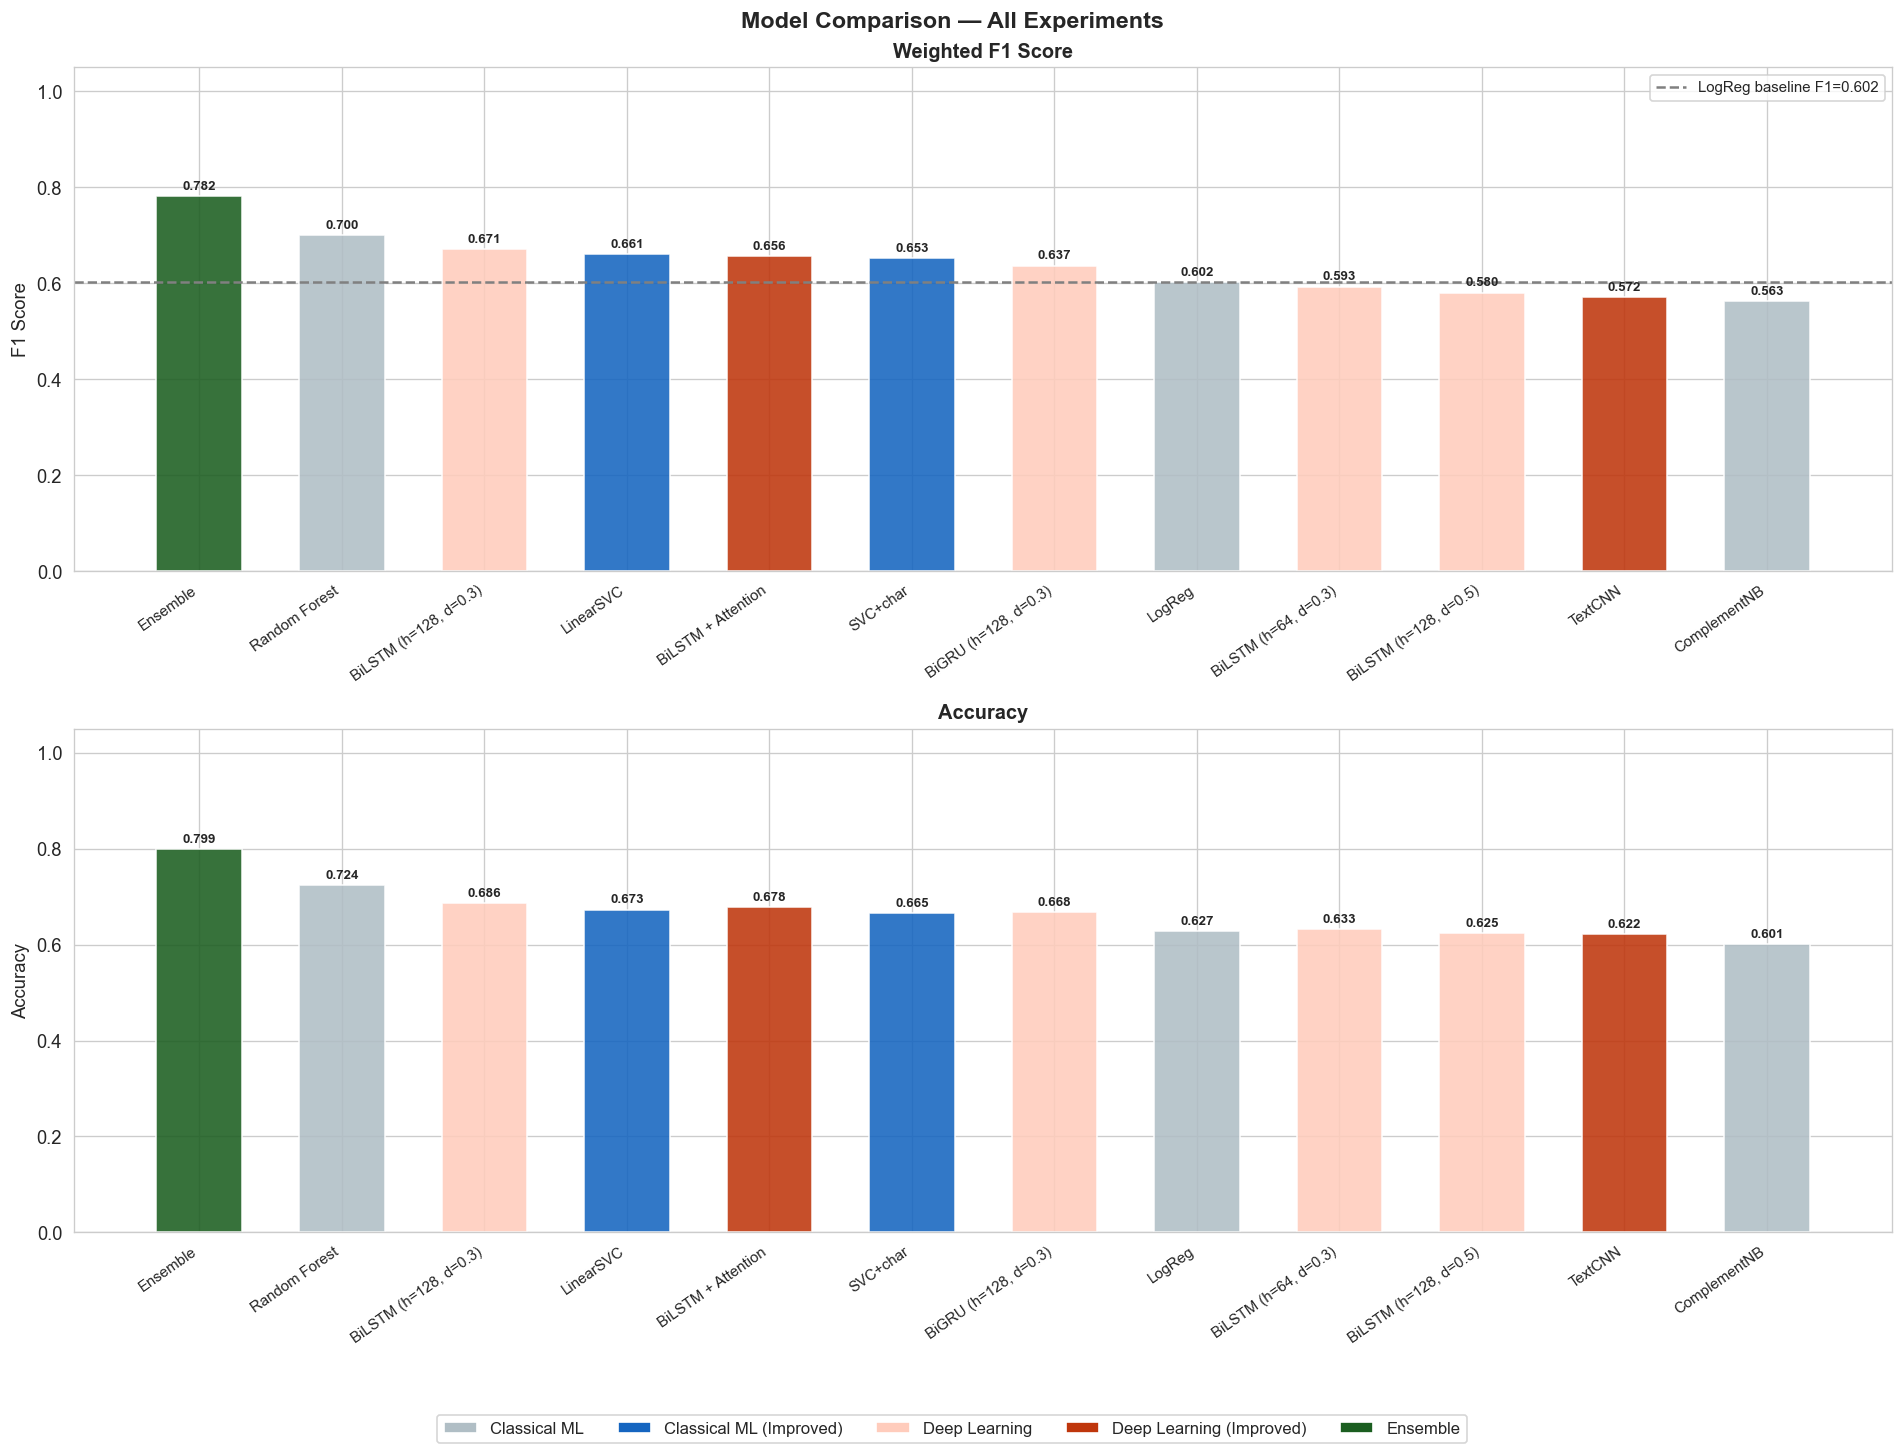

In [29]:
# Final visual comparison — vertical bars
color_map = {
    'Classical ML':            '#B0BEC5',
    'Classical ML (Improved)': '#1565C0',
    'Deep Learning':           '#FFCCBC',
    'Deep Learning (Improved)':'#BF360C',
    'Ensemble':                '#1B5E20',
}

names_sorted  = [n for n, _ in sorted_results]
f1_sorted     = [all_results[n]['f1']  for n in names_sorted]
acc_sorted    = [all_results[n]['acc'] for n in names_sorted]
colors_sorted = [color_map.get(all_results[n]['type'], '#999') for n in names_sorted]

# Shorten names for readability on x-axis
short_names = []
for n in names_sorted:
    n2 = (n.replace('TF-IDF + ', '')
           .replace(' (baseline)', '')
           .replace(' (improved)', '')
           .replace('LinearSVC + char n-grams', 'SVC+char')
           .replace('Ensemble (SVC+BiLSTM+Attn+CNN)', 'Ensemble'))
    short_names.append(n2)

x = range(len(names_sorted))
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Model Comparison — All Experiments', fontsize=14, fontweight='bold')

# F1 chart
bars1 = axes[0].bar(x, f1_sorted, color=colors_sorted, alpha=0.88, width=0.6, edgecolor='white')
axes[0].axhline(baseline_f1, color='gray', linestyle='--', linewidth=1.5,
                label=f'LogReg baseline F1={baseline_f1:.3f}')
axes[0].set_title('Weighted F1 Score', fontweight='bold', fontsize=12)
axes[0].set_ylabel('F1 Score')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(short_names, rotation=35, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
for bar, v in zip(bars1, f1_sorted):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.008,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Accuracy chart
bars2 = axes[1].bar(x, acc_sorted, color=colors_sorted, alpha=0.88, width=0.6, edgecolor='white')
axes[1].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(short_names, rotation=35, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05)
for bar, v in zip(bars2, acc_sorted):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.008,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#B0BEC5', label='Classical ML'),
    Patch(facecolor='#1565C0', label='Classical ML (Improved)'),
    Patch(facecolor='#FFCCBC', label='Deep Learning'),
    Patch(facecolor='#BF360C', label='Deep Learning (Improved)'),
    Patch(facecolor='#1B5E20', label='Ensemble'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

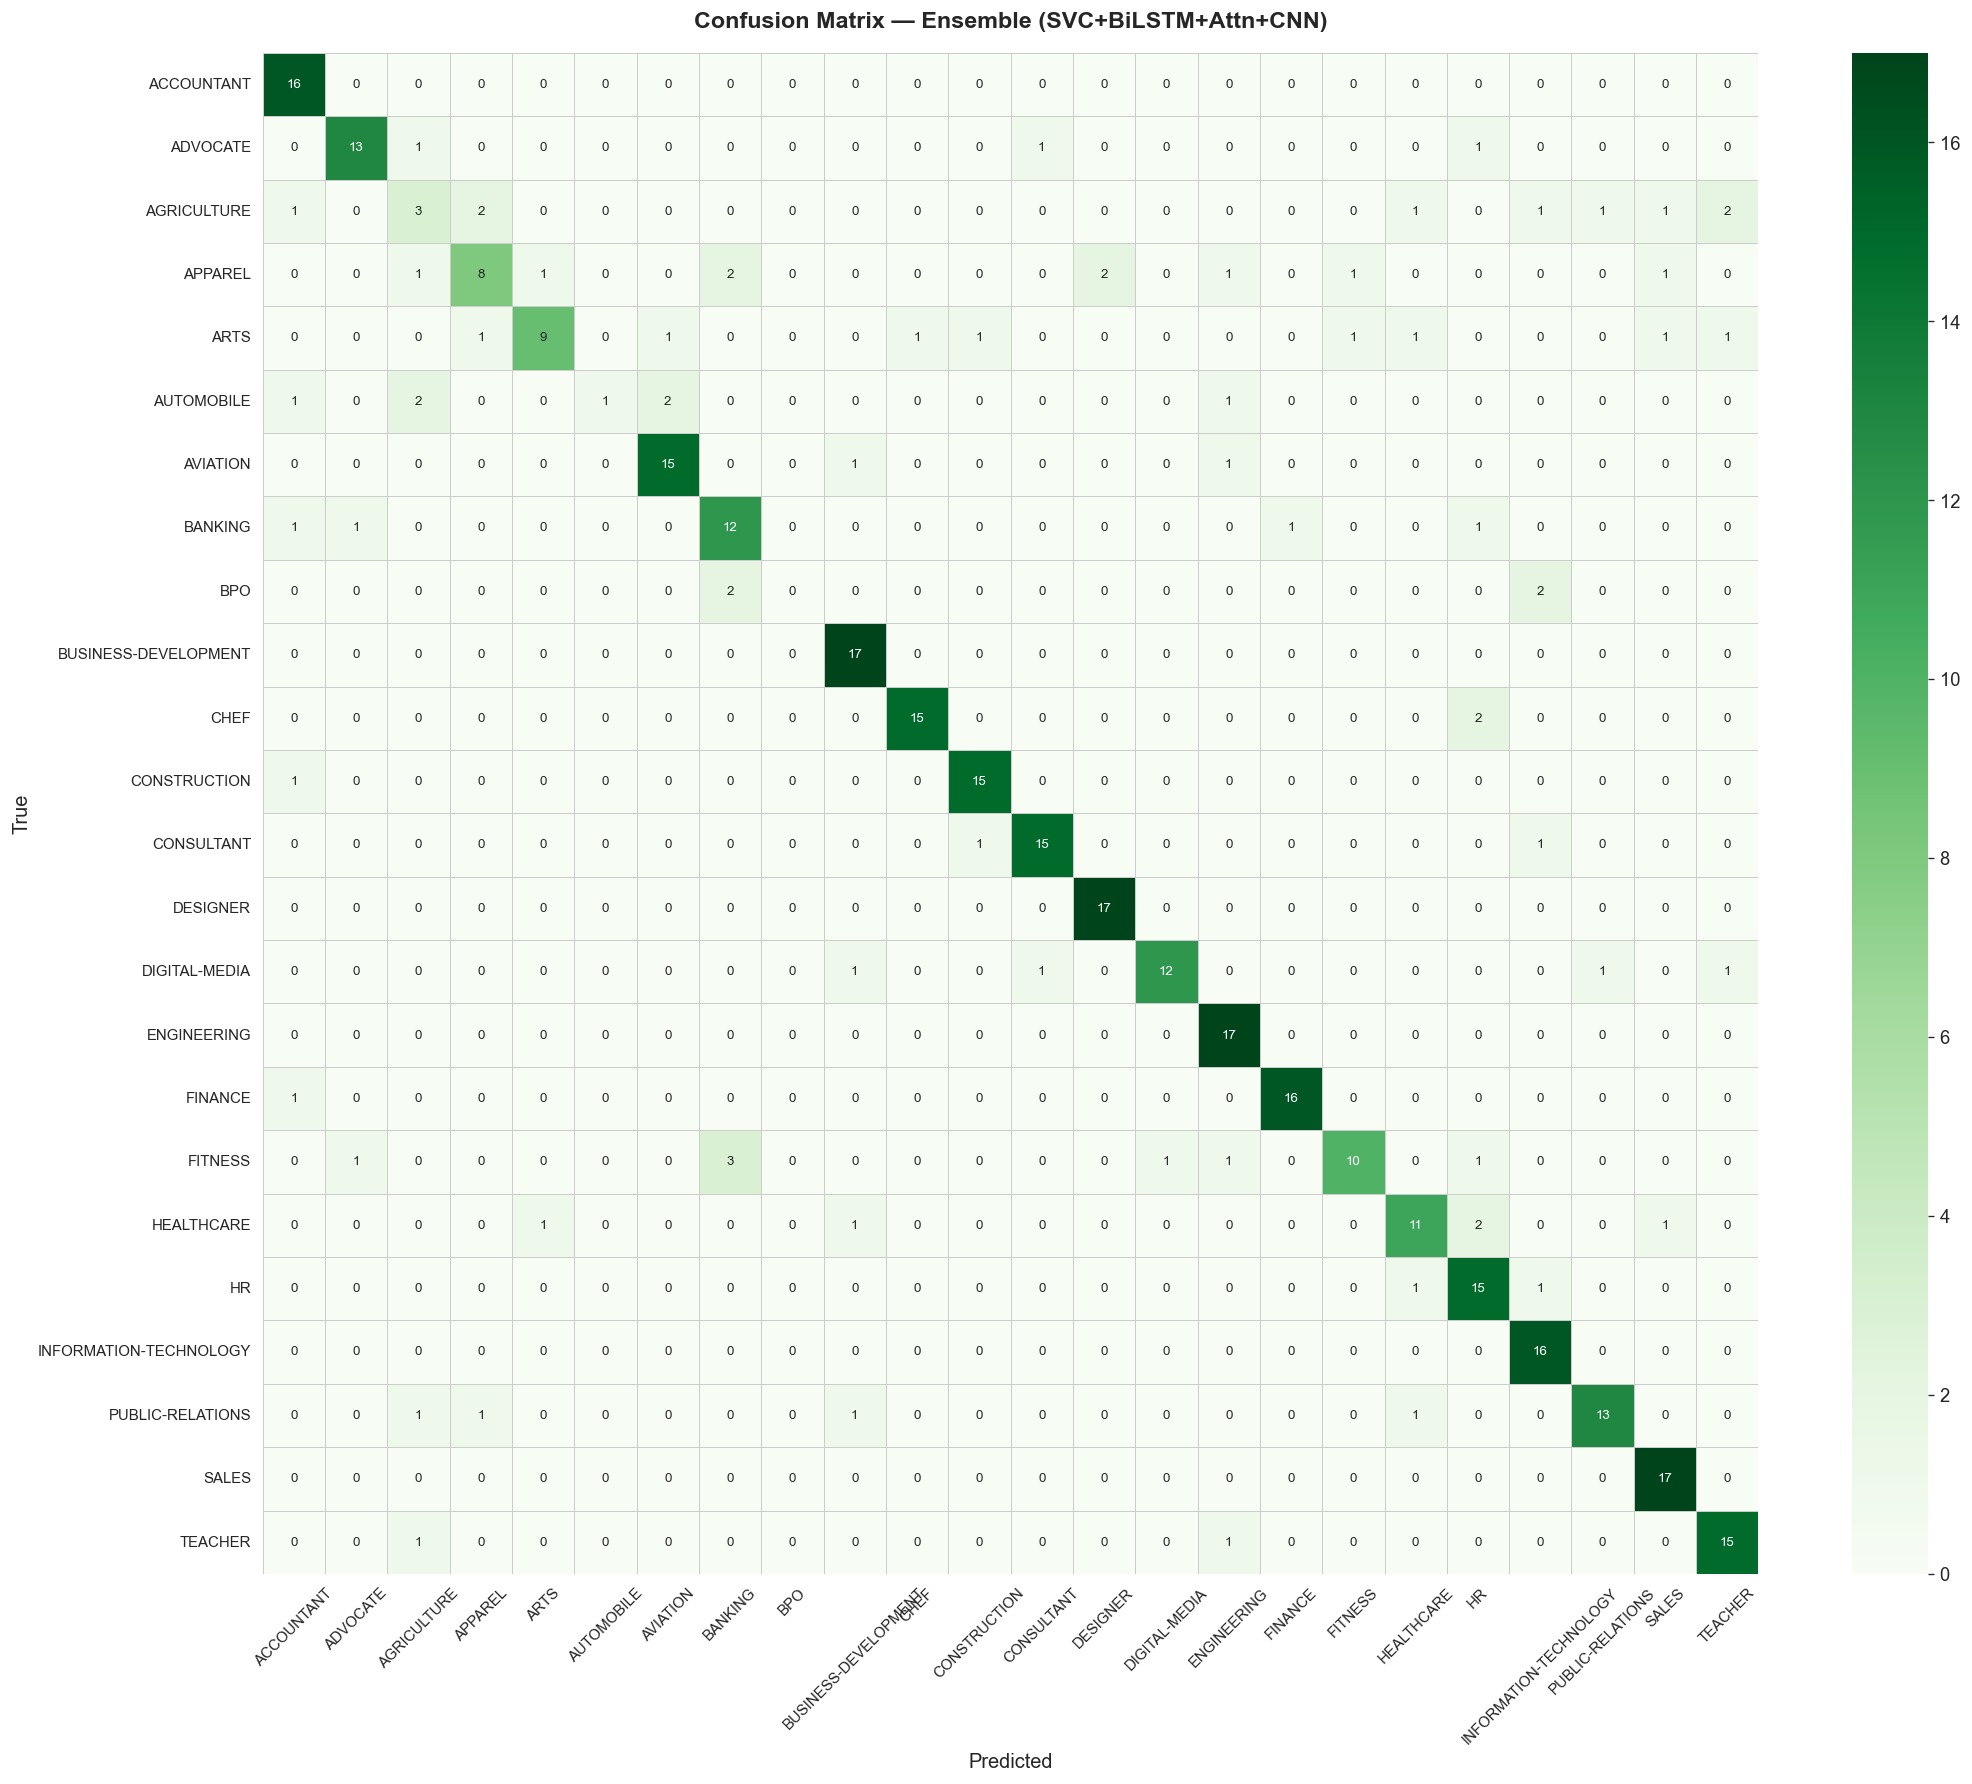


=== CLASSIFICATION REPORT — Best Model ===

                        precision    recall  f1-score   support

            ACCOUNTANT      0.762     1.000     0.865        16
              ADVOCATE      0.867     0.812     0.839        16
           AGRICULTURE      0.333     0.250     0.286        12
               APPAREL      0.667     0.471     0.552        17
                  ARTS      0.818     0.529     0.643        17
            AUTOMOBILE      1.000     0.143     0.250         7
              AVIATION      0.833     0.882     0.857        17
               BANKING      0.632     0.750     0.686        16
                   BPO      0.000     0.000     0.000         4
  BUSINESS-DEVELOPMENT      0.810     1.000     0.895        17
                  CHEF      0.938     0.882     0.909        17
          CONSTRUCTION      0.882     0.938     0.909        16
            CONSULTANT      0.882     0.882     0.882        17
              DESIGNER      0.895     1.000     0.944     

In [30]:
# Confusion matrix of the best overall model
best_name_final = max(all_results, key=lambda k: all_results[k]['f1'])
y_pred_final    = all_results[best_name_final]['y_pred']

cm_final = confusion_matrix(y_te, y_pred_final)
fig, ax  = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.4, linecolor='#cccccc', ax=ax,
            annot_kws={'size': 8})
ax.set_title(f'Confusion Matrix — {best_name_final}',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

print("\n=== CLASSIFICATION REPORT — Best Model ===\n")
print(classification_report(y_te, y_pred_final,
                             target_names=le.classes_, digits=3, zero_division=0))


---
## 4.9 Strategy: Merge Weak Classes into "AUTRE"

### Problem
Some categories have F1 = 0 or very low F1 because:
- **Too few training examples** (BPO: 4 examples, AUTOMOBILE: 7 examples)
- **Vocabulary overlap** with other classes (FITNESS ↔ HEALTHCARE, ARTS ↔ DIGITAL-MEDIA)

Trying to classify these pulls the whole model down.

### Solution
Set a threshold on per-class F1.
Any class whose F1 < threshold → relabelled **AUTRE** (other).

The model then has **fewer, cleaner classes** to learn.

### Why this is valid
- In production, it is better to say *"I don't know"* than to give a wrong answer
- Concentrating training data on learnable classes improves generalisation
- This is standard practice in industrial NLP pipelines


### Step 1 — Analyse per-class F1 and choose threshold

In [31]:
from sklearn.metrics import classification_report

# Use the best model's predictions (computed in 4.8)
best_name_for_autre = max(all_results, key=lambda k: all_results[k]['f1'])
y_pred_for_autre    = all_results[best_name_for_autre]['y_pred']

report_dict = classification_report(
    y_te, y_pred_for_autre,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)

# Build a DataFrame for easy visualisation
perf_df = pd.DataFrame([
    {'Category': cls,
     'F1':        round(report_dict[cls]['f1-score'],   3),
     'Precision': round(report_dict[cls]['precision'],  3),
     'Recall':    round(report_dict[cls]['recall'],     3),
     'Support':   int(report_dict[cls]['support'])}
    for cls in le.classes_
]).sort_values('F1')

print("Per-class F1 scores (sorted ascending):")
print(perf_df.to_string(index=False))


Per-class F1 scores (sorted ascending):
              Category    F1  Precision  Recall  Support
                   BPO 0.000      0.000   0.000        4
            AUTOMOBILE 0.250      1.000   0.143        7
           AGRICULTURE 0.286      0.333   0.250       12
               APPAREL 0.552      0.667   0.471       17
                  ARTS 0.643      0.818   0.529       17
               BANKING 0.686      0.632   0.750       16
               FITNESS 0.690      0.833   0.588       17
            HEALTHCARE 0.710      0.733   0.688       16
                    HR 0.769      0.682   0.882       17
      PUBLIC-RELATIONS 0.812      0.867   0.765       17
         DIGITAL-MEDIA 0.828      0.923   0.750       16
               TEACHER 0.833      0.789   0.882       17
              ADVOCATE 0.839      0.867   0.812       16
              AVIATION 0.857      0.833   0.882       17
INFORMATION-TECHNOLOGY 0.865      0.762   1.000       16
            ACCOUNTANT 0.865      0.762   1.000 

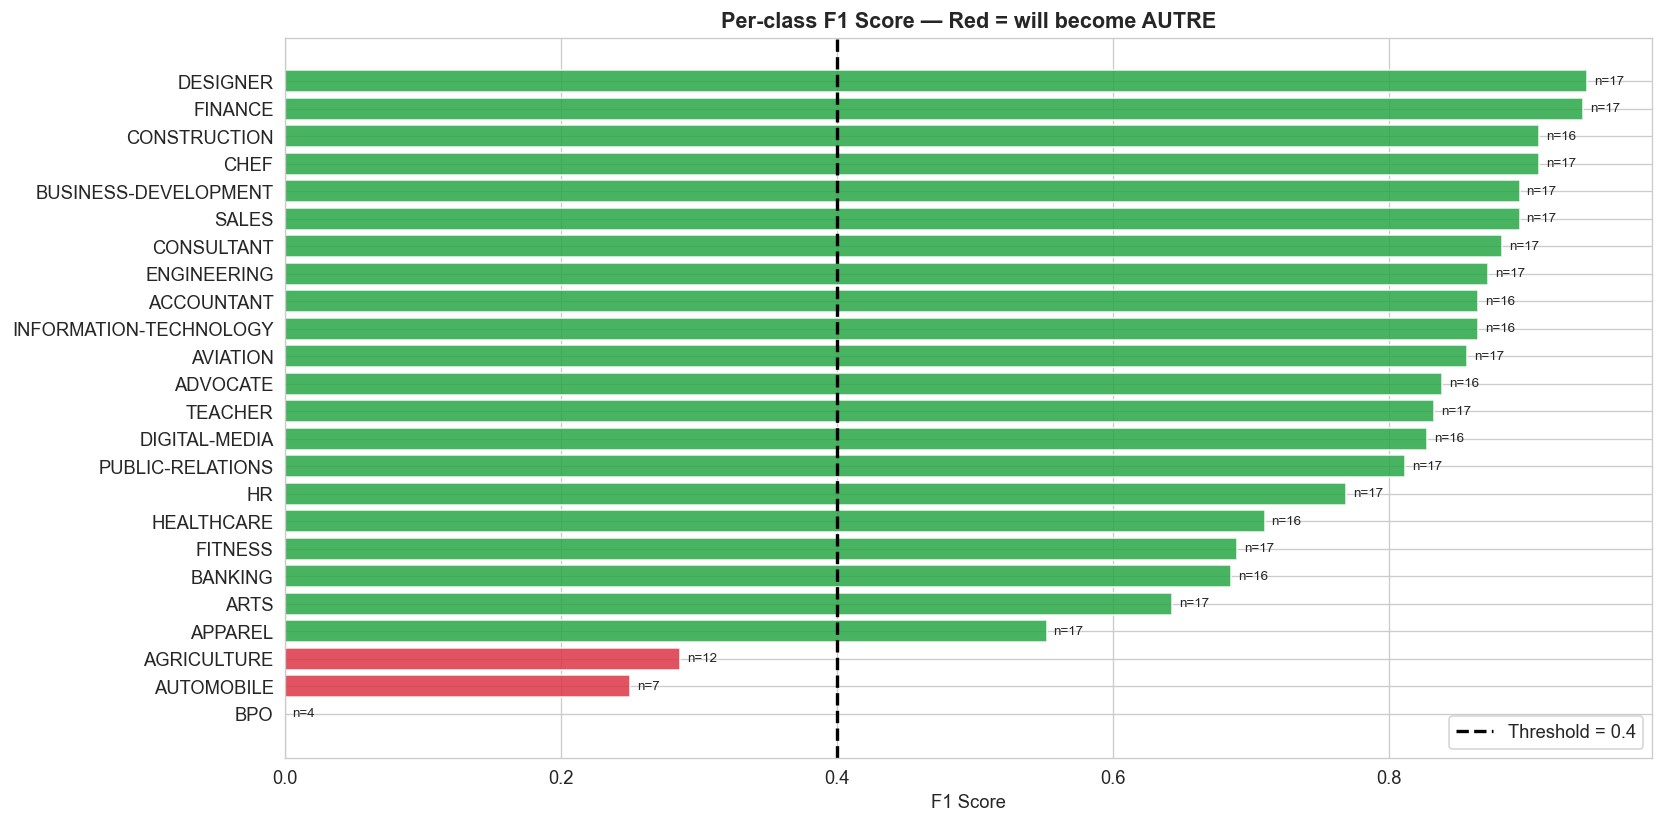


Threshold F1 < 0.4:
  Weak -> AUTRE (3 classes): ['BPO', 'AUTOMOBILE', 'AGRICULTURE']
  Strong -> kept (21 classes): ['APPAREL', 'ARTS', 'BANKING', 'FITNESS', 'HEALTHCARE', 'HR', 'PUBLIC-RELATIONS', 'DIGITAL-MEDIA', 'TEACHER', 'ADVOCATE', 'AVIATION', 'INFORMATION-TECHNOLOGY', 'ACCOUNTANT', 'ENGINEERING', 'CONSULTANT', 'SALES', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'FINANCE', 'DESIGNER']


In [32]:
# Bar chart coloured by threshold
THRESHOLD = 0.40   # <-- change this to explore different thresholds

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#dc3545' if f < THRESHOLD else '#28a745'
          for f in perf_df['F1']]
bars = ax.barh(perf_df['Category'], perf_df['F1'], color=colors, alpha=0.85)
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {THRESHOLD}')
ax.set_title('Per-class F1 Score — Red = will become AUTRE', fontweight='bold', fontsize=13)
ax.set_xlabel('F1 Score')
ax.legend(fontsize=11)

# Annotate support
for bar, (_, row) in zip(bars, perf_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"n={row['Support']}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

weak   = perf_df[perf_df['F1'] < THRESHOLD]['Category'].tolist()
strong = perf_df[perf_df['F1'] >= THRESHOLD]['Category'].tolist()
print(f"\nThreshold F1 < {THRESHOLD}:")
print(f"  Weak -> AUTRE ({len(weak)} classes): {weak}")
print(f"  Strong -> kept ({len(strong)} classes): {strong}")


### Step 2 — Rebuild dataset with AUTRE class

Class distribution after merging:
Category
AUTRE                     121
BUSINESS-DEVELOPMENT      120
INFORMATION-TECHNOLOGY    120
ADVOCATE                  118
FINANCE                   118
CHEF                      118
ACCOUNTANT                118
ENGINEERING               118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
BANKING                   115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96

Total classes : 22  (was 24)
AUTRE examples: 121


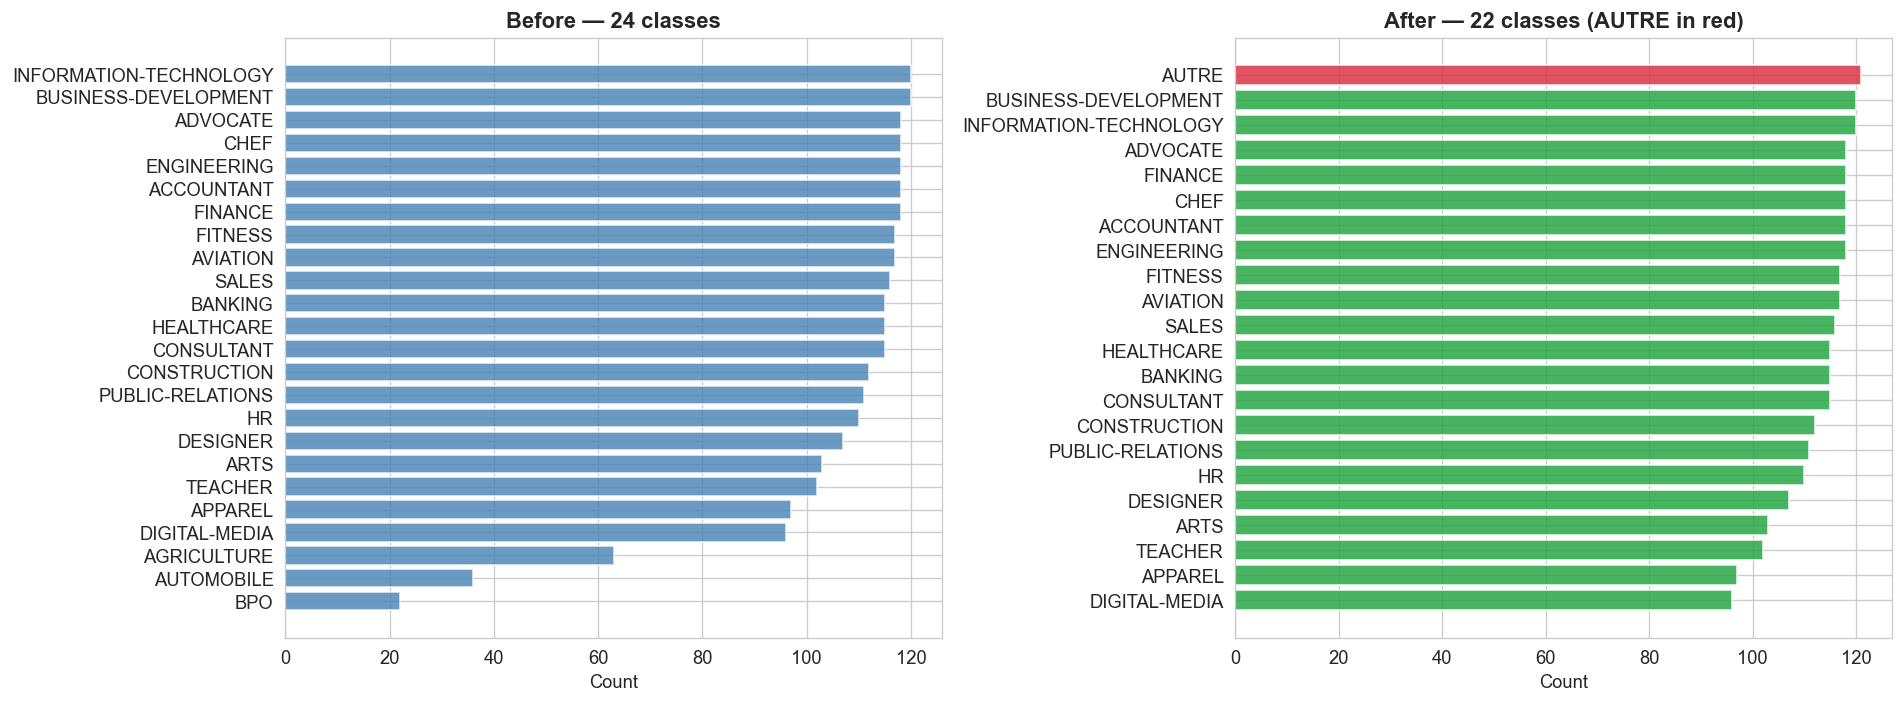

In [33]:
# Remap weak categories to AUTRE
df_autre = df.copy()
df_autre['Category'] = df_autre['Category'].apply(
    lambda c: 'AUTRE' if c in weak else c
)

print("Class distribution after merging:")
counts = df_autre['Category'].value_counts()
print(counts.to_string())
print(f"\nTotal classes : {df_autre['Category'].nunique()}  "
      f"(was {df['Category'].nunique()})")
print(f"AUTRE examples: {(df_autre['Category'] == 'AUTRE').sum()}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before
orig_counts = df['Category'].value_counts()
axes[0].barh(orig_counts.index[::-1], orig_counts.values[::-1],
             color='steelblue', alpha=0.8)
axes[0].set_title(f'Before — {df["Category"].nunique()} classes',
                  fontweight='bold')
axes[0].set_xlabel('Count')

# After
axes[1].barh(counts.index[::-1], counts.values[::-1],
             color=['#dc3545' if c == 'AUTRE' else '#28a745'
                    for c in counts.index[::-1]],
             alpha=0.85)
axes[1].set_title(f'After — {df_autre["Category"].nunique()} classes (AUTRE in red)',
                  fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


### Step 3 — Retrain models on new dataset

In [34]:
# Prepare new train/test split
X_tr2, X_te2, y_tr2, y_te2, le2 = prepare_data(df_autre, max_samples=2000)
num_classes2 = len(le2.classes_)
print(f"New classes ({num_classes2}): {le2.classes_.tolist()}")
print(f"Train: {len(X_tr2)}  Test: {len(X_te2)}")

results_autre = {}   # separate dict to compare before/after

# ── Classical: LinearSVC + char n-grams ─────────────────────────────────────
word_vec2 = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                             max_features=15000, sublinear_tf=True,
                             stop_words='english')
char_vec2 = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                             max_features=15000, sublinear_tf=True)
import scipy.sparse as sp
X_tr2_combined = sp.hstack([word_vec2.fit_transform(X_tr2),
                              char_vec2.fit_transform(X_tr2)])
X_te2_combined  = sp.hstack([word_vec2.transform(X_te2),
                               char_vec2.transform(X_te2)])

t = time.time()
svc2 = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3
)
svc2.fit(X_tr2_combined, y_tr2)
y_pred_svc2 = svc2.predict(X_te2_combined)
results_autre['LinearSVC + char (AUTRE)'] = {
    'acc': accuracy_score(y_te2, y_pred_svc2),
    'f1':  f1_score(y_te2, y_pred_svc2, average='weighted'),
    'time': time.time() - t,
    'y_pred': y_pred_svc2
}
r = results_autre['LinearSVC + char (AUTRE)']
print(f"LinearSVC+char  Acc={r['acc']:.4f}  F1={r['f1']:.4f}  Time={r['time']:.1f}s")


[Data] Train=1584  Test=396  Classes=22
New classes (22): ['ACCOUNTANT', 'ADVOCATE', 'APPAREL', 'ARTS', 'AUTRE', 'AVIATION', 'BANKING', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Train: 1584  Test: 396
LinearSVC+char  Acc=0.6970  F1=0.6905  Time=9.6s


In [35]:
# ── Deep Learning: BiLSTM + Attention ────────────────────────────────────────
vocab2 = Vocabulary(max_size=8000, min_freq=2)
vocab2.build(X_tr2)

tr_loader2 = DataLoader(ResumeDataset(X_tr2, y_tr2, vocab2),
                         batch_size=32, shuffle=True)
te_loader2 = DataLoader(ResumeDataset(X_te2, y_te2, vocab2),
                         batch_size=64)

print("[Attention BiLSTM on AUTRE dataset]")
attn2 = AttentionBiLSTM(vocab2.size, 128, 128, num_classes2, dropout=0.3)

def train_and_eval(model, loader_tr, loader_te, config):
    history = train_deep(model, loader_tr, loader_te, config)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in loader_te:
            preds.extend(model(x).argmax(1).numpy())
            trues.extend(y.numpy())
    return model, history, np.array(preds), np.array(trues)

m_attn2, h_attn2, y_pred_attn2, y_true2 = train_and_eval(
    attn2, tr_loader2, te_loader2,
    {'name': 'Attention_AUTRE', 'lr': 1e-3, 'epochs': 10,
     'weight_decay': 1e-5, 'scheduler_step': 5, 'patience': 3}
)
results_autre['BiLSTM+Attention (AUTRE)'] = {
    'acc':  accuracy_score(y_true2, y_pred_attn2),
    'f1':   f1_score(y_true2, y_pred_attn2, average='weighted'),
    'time': h_attn2['train_time'],
    'y_pred': y_pred_attn2
}
r = results_autre['BiLSTM+Attention (AUTRE)']
print(f"Attention BiLSTM  Acc={r['acc']:.4f}  F1={r['f1']:.4f}  Time={r['time']:.0f}s")


[Vocab] Size: 8000
[Attention BiLSTM on AUTRE dataset]

[Train] Attention_AUTRE  lr=0.001  epochs=10  patience=3
  Epoch 01/10  loss 3.0734/2.9591  acc  0.0802/0.2020
  Epoch 02/10  loss 2.5699/2.0310  acc  0.2525/0.4369
  Epoch 03/10  loss 1.8315/1.4744  acc  0.4804/0.5758
  Epoch 04/10  loss 1.3954/1.2369  acc  0.6117/0.6338
  Epoch 05/10  loss 1.1294/1.0855  acc  0.6585/0.6364
  Epoch 06/10  loss 0.9356/1.0608  acc  0.7266/0.6692
  Epoch 07/10  loss 0.8224/1.0254  acc  0.7569/0.6843
  Epoch 08/10  loss 0.7485/1.0429  acc  0.7841/0.6970
  Epoch 09/10  loss 0.6798/1.0092  acc  0.8062/0.7146
  Epoch 10/10  loss 0.6477/0.9699  acc  0.8062/0.7273
  Finished in 148.1s
Attention BiLSTM  Acc=0.7273  F1=0.7170  Time=148s


In [36]:
# ── Ensemble on AUTRE dataset ─────────────────────────────────────────────────
proba_svc2  = svc2.predict_proba(X_te2_combined)
proba_attn2 = get_dl_proba(m_attn2, te_loader2)

ensemble2_proba  = (proba_svc2 + proba_attn2) / 2
y_pred_ens2      = ensemble2_proba.argmax(axis=1)
results_autre['Ensemble (AUTRE)'] = {
    'acc':  accuracy_score(y_true2, y_pred_ens2),
    'f1':   f1_score(y_true2, y_pred_ens2, average='weighted'),
    'time': 0.0,
    'y_pred': y_pred_ens2
}
r = results_autre['Ensemble (AUTRE)']
print(f"Ensemble          Acc={r['acc']:.4f}  F1={r['f1']:.4f}")


Ensemble          Acc=0.8030  F1=0.7913


### Step 4 — Before vs After comparison

In [37]:
# Best scores from original 24-class models
best_original_f1  = max(v['f1']  for v in all_results.values())
best_original_acc = max(v['acc'] for v in all_results.values())
best_autre_f1     = max(v['f1']  for v in results_autre.values())
best_autre_acc    = max(v['acc'] for v in results_autre.values())

print("=" * 60)
print("BEFORE vs AFTER — AUTRE strategy")
print("=" * 60)
print(f"{'':30} {'Accuracy':>10} {'F1 (w)':>10}")
print("-" * 52)
print(f"{'Best (24 classes, no AUTRE)':<30} {best_original_acc:>10.4f} {best_original_f1:>10.4f}")
print(f"{'Best (AUTRE strategy)':<30} {best_autre_acc:>10.4f} {best_autre_f1:>10.4f}")
print("-" * 52)
gain_f1  = best_autre_f1  - best_original_f1
gain_acc = best_autre_acc - best_original_acc
print(f"{'Improvement':<30} {gain_acc:>+10.4f} {gain_f1:>+10.4f}")
print("=" * 60)


BEFORE vs AFTER — AUTRE strategy
                                 Accuracy     F1 (w)
----------------------------------------------------
Best (24 classes, no AUTRE)        0.7989     0.7823
Best (AUTRE strategy)              0.8030     0.7913
----------------------------------------------------
Improvement                       +0.0041    +0.0090


In [38]:
# Detailed comparison table
print(f"{'Model':<35} {'Classes':>8} {'Accuracy':>10} {'F1 (w)':>10}")
print("=" * 68)

# Original models (top 5)
top5_orig = sorted(all_results.items(), key=lambda x: x[1]['f1'], reverse=True)[:5]
for name, r in top5_orig:
    print(f"{name:<35} {'24':>8} {r['acc']:>10.4f} {r['f1']:>10.4f}")

print("-" * 68)

# AUTRE models
for name, r in sorted(results_autre.items(), key=lambda x: x[1]['f1'], reverse=True):
    n_cls = str(num_classes2)
    print(f"{name:<35} {n_cls:>8} {r['acc']:>10.4f} {r['f1']:>10.4f}  <- AUTRE")

print("=" * 68)


Model                                Classes   Accuracy     F1 (w)
Ensemble (SVC+BiLSTM+Attn+CNN)            24     0.7989     0.7823
TF-IDF + Random Forest                    24     0.7239     0.7001
BiLSTM (h=128, d=0.3)                     24     0.6863     0.6714
LinearSVC (improved)                      24     0.6729     0.6606
BiLSTM + Attention (improved)             24     0.6783     0.6560
--------------------------------------------------------------------
Ensemble (AUTRE)                          22     0.8030     0.7913  <- AUTRE
BiLSTM+Attention (AUTRE)                  22     0.7273     0.7170  <- AUTRE
LinearSVC + char (AUTRE)                  22     0.6970     0.6905  <- AUTRE


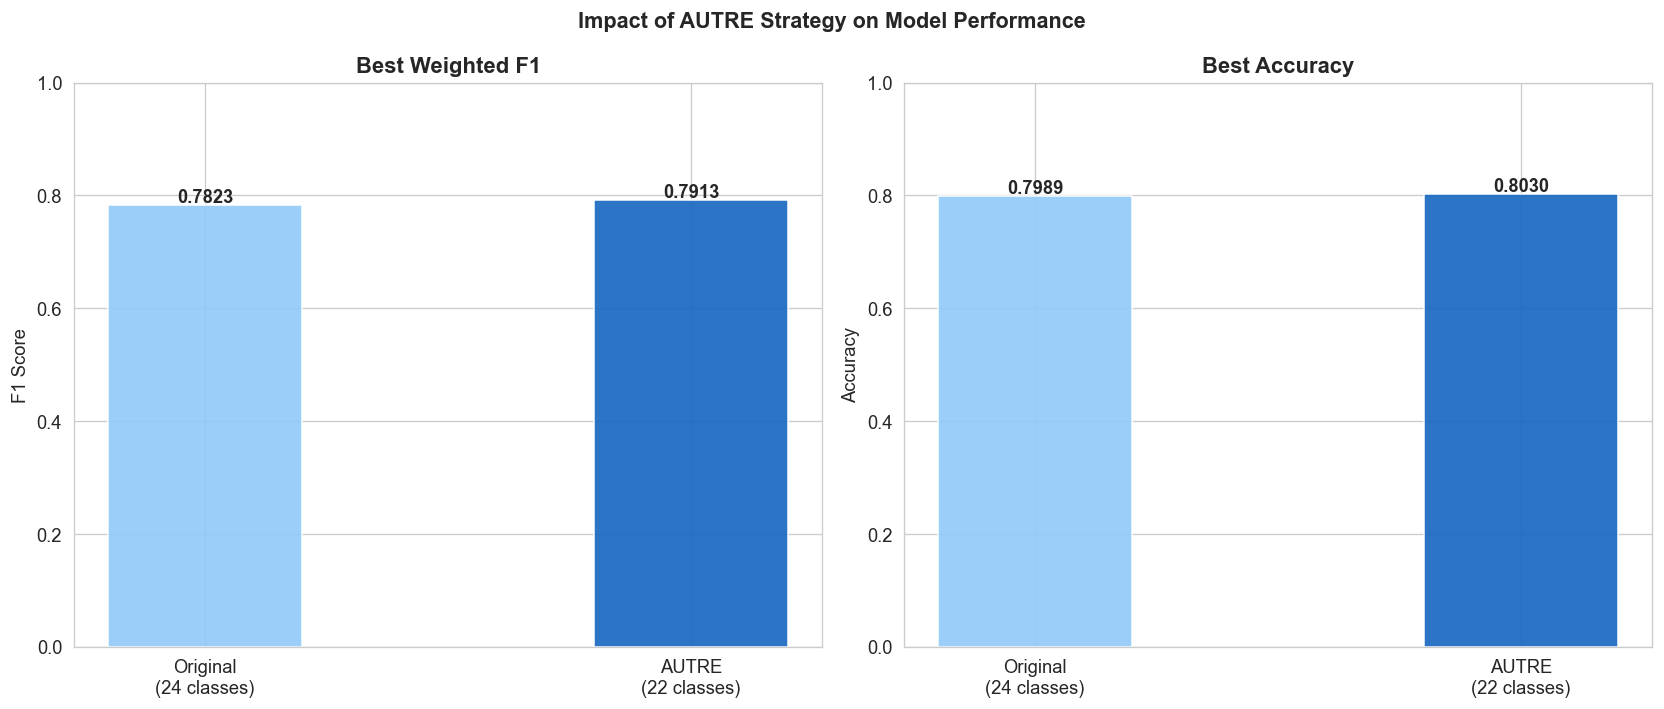

In [39]:
# Visual before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of AUTRE Strategy on Model Performance', fontsize=13, fontweight='bold')

labels  = ['Original\n(24 classes)', 'AUTRE\n(' + str(num_classes2) + ' classes)']
f1s     = [best_original_f1,  best_autre_f1]
accs    = [best_original_acc, best_autre_acc]
colors  = ['#90CAF9', '#1565C0']

axes[0].bar(labels, f1s, color=colors, alpha=0.9, width=0.4)
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_title('Best Weighted F1', fontweight='bold')
axes[0].set_ylabel('F1 Score')

axes[1].bar(labels, accs, color=colors, alpha=0.9, width=0.4)
for i, v in enumerate(accs):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_title('Best Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()


### Confusion Matrix — Best model with AUTRE

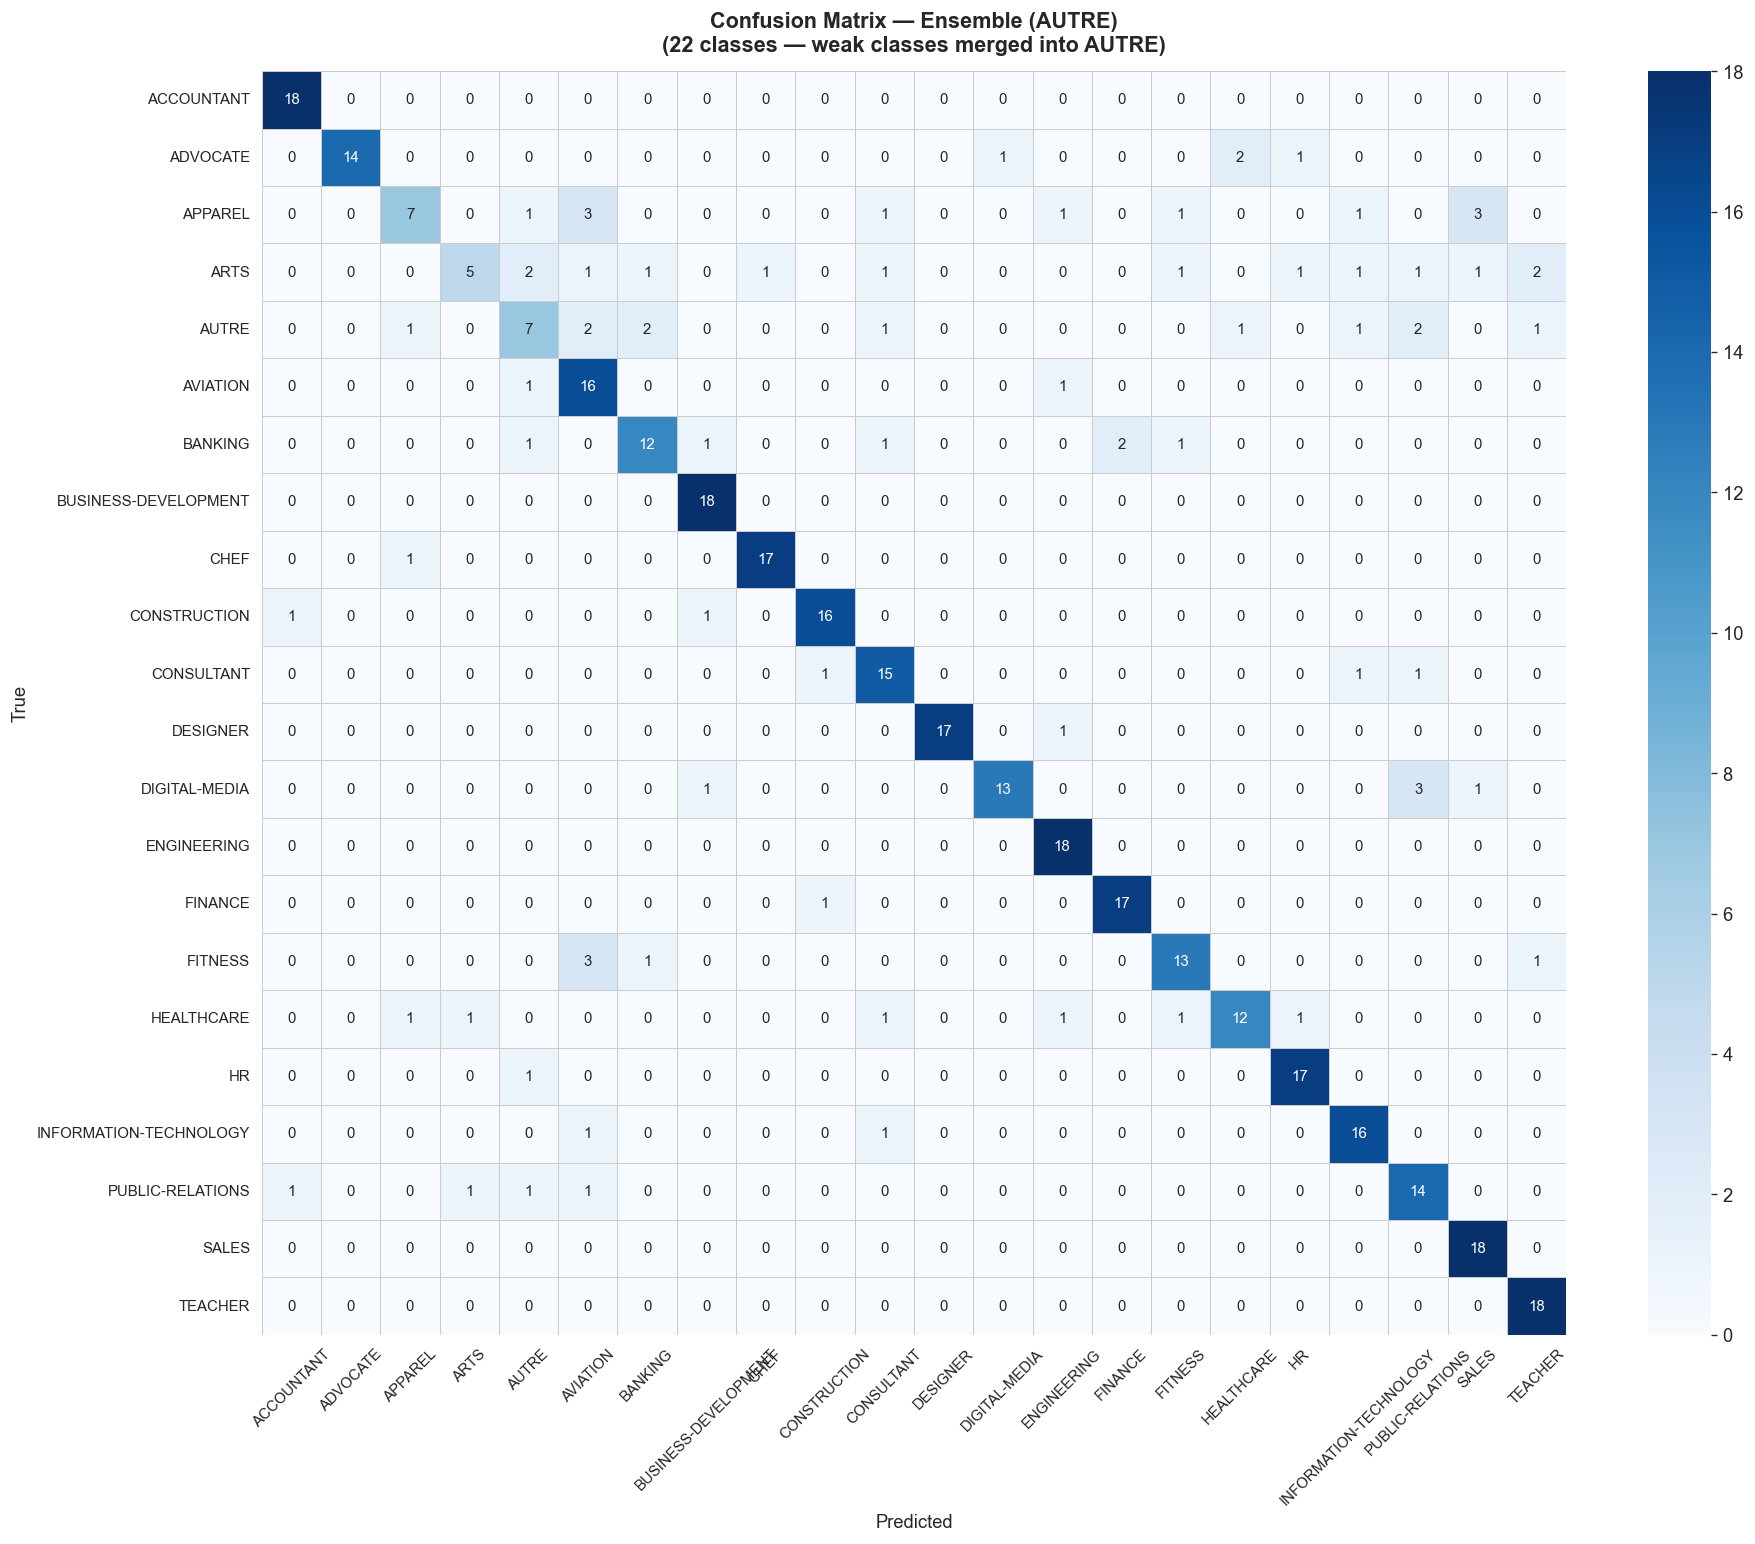


=== CLASSIFICATION REPORT ===

                        precision    recall  f1-score   support

            ACCOUNTANT      0.900     1.000     0.947        18
              ADVOCATE      1.000     0.778     0.875        18
               APPAREL      0.700     0.389     0.500        18
                  ARTS      0.714     0.278     0.400        18
                 AUTRE      0.500     0.389     0.438        18
              AVIATION      0.593     0.889     0.711        18
               BANKING      0.750     0.667     0.706        18
  BUSINESS-DEVELOPMENT      0.857     1.000     0.923        18
                  CHEF      0.944     0.944     0.944        18
          CONSTRUCTION      0.889     0.889     0.889        18
            CONSULTANT      0.714     0.833     0.769        18
              DESIGNER      1.000     0.944     0.971        18
         DIGITAL-MEDIA      0.929     0.722     0.812        18
           ENGINEERING      0.818     1.000     0.900        18
       

In [40]:
best_autre_name   = max(results_autre, key=lambda k: results_autre[k]['f1'])
y_pred_best_autre = results_autre[best_autre_name]['y_pred']

cm_autre = confusion_matrix(y_true2, y_pred_best_autre)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm_autre, annot=True, fmt='d', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_,
            linewidths=0.4, linecolor='#cccccc', ax=ax,
            annot_kws={'size': 9})
ax.set_title(f'Confusion Matrix — {best_autre_name}\n'
             f'({num_classes2} classes — weak classes merged into AUTRE)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_true2, y_pred_best_autre,
                             target_names=le2.classes_, digits=3, zero_division=0))


In [41]:
# ── Save best models so Streamlit app can load them without retraining ────────
import joblib, pickle, json as _json, os

model_dir = os.path.join('..', 'data', 'models')
os.makedirs(model_dir, exist_ok=True)

# Best models (AUTRE strategy — used by Streamlit app)
joblib.dump(svc2,       os.path.join(model_dir, 'autre_svc.pkl'))
joblib.dump(word_vec2,  os.path.join(model_dir, 'autre_word_vec.pkl'))
joblib.dump(char_vec2,  os.path.join(model_dir, 'autre_char_vec.pkl'))
joblib.dump(le2,        os.path.join(model_dir, 'autre_le.pkl'))

# BiLSTM + Attention weights (optional — for inference in notebook)
import torch
torch.save(m_attn2.state_dict(), os.path.join(model_dir, 'autre_lstm.pt'))

with open(os.path.join(model_dir, 'vocab.pkl'), 'wb') as f:
    pickle.dump(vocab2, f)

config_info = {
    'model_type':  'AttentionBiLSTM',
    'vocab_size':  vocab2.size,
    'embed_dim':   128,
    'hidden_dim':  128,
    'num_classes': num_classes2,
    'num_layers':  2,
    'dropout':     0.3,
    'class_names': le2.classes_.tolist(),
    'weak_classes_merged': weak,
    'threshold': THRESHOLD,
}
with open(os.path.join(model_dir, 'lstm_config.json'), 'w') as f:
    _json.dump(config_info, f, indent=2)

print("Saved to data/models/:")
for fname in sorted(os.listdir(model_dir)):
    size = os.path.getsize(os.path.join(model_dir, fname))
    print(f"  {fname:<35} {size/1024:>8.1f} KB")
print("\nStreamlit app will use autre_svc + autre_word_vec + autre_char_vec + autre_le")

Saved to data/models/:
  autre_char_vec.pkl                     502.9 KB
  autre_le.pkl                             0.9 KB
  autre_lstm.pt                         6605.7 KB
  autre_svc.pkl                        15475.9 KB
  autre_word_vec.pkl                     615.3 KB
  baseline_clf.pkl                      1876.2 KB
  baseline_vec.pkl                       402.2 KB
  label_encoder.pkl                        0.9 KB
  lstm_best.pt                          6606.1 KB
  lstm_config.json                         0.7 KB
  vocab.pkl                              166.6 KB

Streamlit app will use autre_svc + autre_word_vec + autre_char_vec + autre_le


---
# PIPELINE 2 — CV ↔ Job Matching

**Goal:** Given a resume, find the most relevant job postings from the database.

**Input:** Raw resume text
**Output:** Ranked list of job postings with similarity scores
**Method:** TF-IDF vectorisation + cosine similarity

**Why TF-IDF cosine similarity?**
- Unsupervised — no labels needed
- Fast and scalable (5,000 jobs in < 1 second)
- Interpretable: high score = many shared keywords

## Methods Tested

| # | Method | max_features | ngram_range | Notes |
|---|---|---|---|---|
| 1 | TF-IDF Basic | 5,000 | (1,1) | Unigrams only |
| 2 | TF-IDF Standard | 15,000 | (1,2) | Bigrams — captures phrases |
| 3 | TF-IDF Extended | 20,000 | (1,3) | Trigrams — longer phrases |

## Evaluation Strategy

Since there are no ground-truth labels for "which job is correct for this CV", we use:
1. **Qualitative evaluation** — inspect top matches manually for different categories
2. **Keyword overlap score** — % of job description keywords present in the CV
3. **Category consistency** — check if matched job title is semantically related to CV category

### 5.1 Load Job Descriptions Dataset

In [42]:
jobs_df = load_job_descriptions(JOBS_CSV, max_rows=5000)
print(f"Job descriptions loaded: {jobs_df.shape}")
print(f"Columns: {jobs_df.columns.tolist()}")
print()
print("Sample job postings:")
print(jobs_df[['Job Title', 'Role', 'Location']].head(8).to_string())

[Jobs] Loaded 5000 job descriptions
Job descriptions loaded: (5000, 6)
Columns: ['Job Title', 'Role', 'Job Description', 'Skills', 'Location', 'match_text']

Sample job postings:
                      Job Title                       Role     Location
0  Digital Marketing Specialist       Social Media Manager      Douglas
1                 Web Developer     Frontend Web Developer     Ashgabat
2            Operations Manager    Quality Control Manager        Macao
3              Network Engineer  Wireless Network Engineer   Porto-Novo
4                 Event Manager         Conference Manager     Santiago
5               Software Tester  Quality Assurance Analyst     Brussels
6                       Teacher          Classroom Teacher  George Town
7                UX/UI Designer    User Interface Designer   SÃ£o TomÃ©


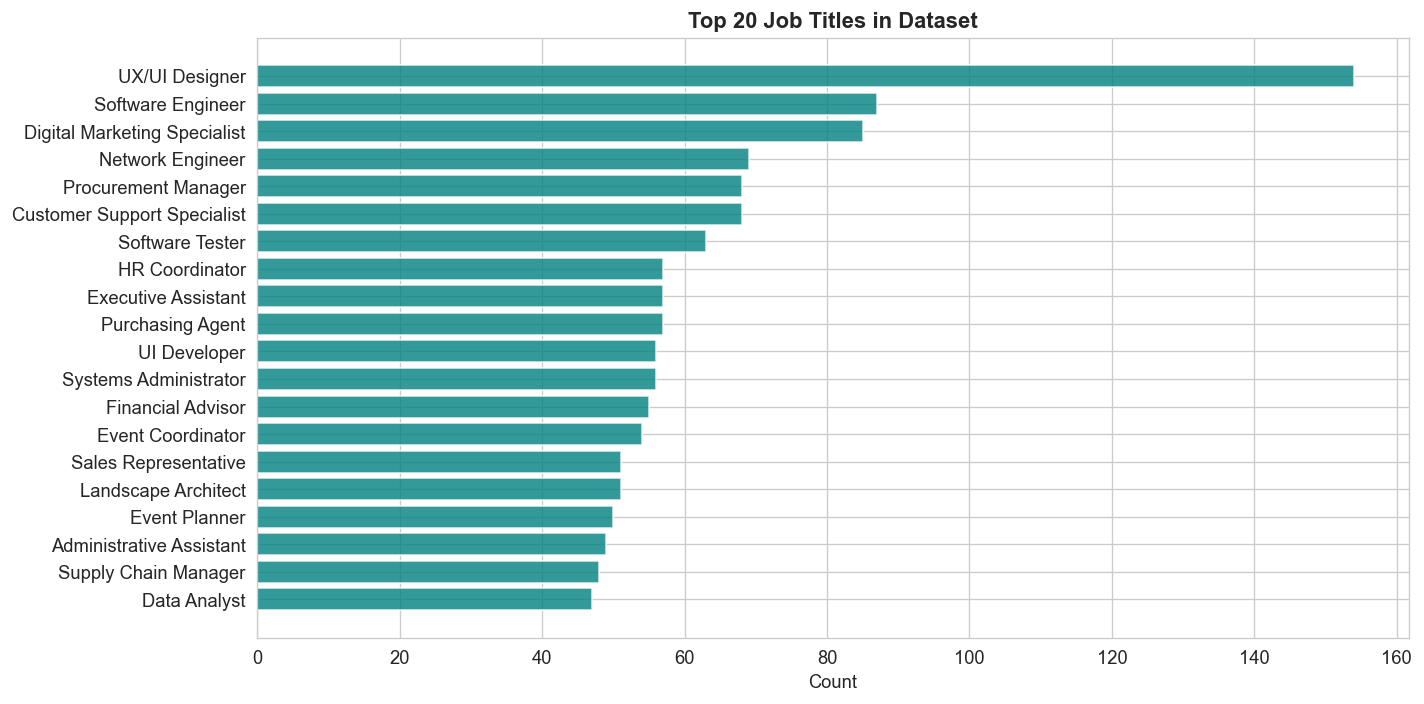

In [43]:
# Job title distribution (top 20)
title_counts = jobs_df['Job Title'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(title_counts.index[::-1], title_counts.values[::-1], color='teal', alpha=0.8)
ax.set_title('Top 20 Job Titles in Dataset', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

### 5.2 Method Comparison — 3 TF-IDF Configurations

In [44]:
def match_config(cv_text, jobs_df, max_features, ngram_range, top_k=5):
    cv_clean = clean_text(cv_text)
    corpus   = [cv_clean] + jobs_df['match_text'].tolist()
    tfidf    = TfidfVectorizer(max_features=max_features, stop_words='english',
                               ngram_range=ngram_range)
    matrix   = tfidf.fit_transform(corpus)
    scores   = cosine_similarity(matrix[0:1], matrix[1:]).flatten()
    jdf      = jobs_df.copy()
    jdf['score'] = scores
    return jdf.nlargest(top_k, 'score')[['Job Title', 'Role', 'score']].reset_index(drop=True)

configs = [
    {'max_features': 5000,  'ngram_range': (1,1), 'label': 'Basic (5k, unigrams)'},
    {'max_features': 15000, 'ngram_range': (1,2), 'label': 'Standard (15k, bigrams)'},
    {'max_features': 20000, 'ngram_range': (1,3), 'label': 'Extended (20k, trigrams)'},
]

# Test on one IT resume
it_cv = df[df['Category'] == 'INFORMATION-TECHNOLOGY']['Resume_str'].iloc[0]
print(f"IT resume preview: {clean_text(it_cv)[:200]}...\n")

for cfg in configs:
    matches = match_config(it_cv, jobs_df, cfg['max_features'], cfg['ngram_range'])
    print(f"\n--- {cfg['label']} ---")
    for _, row in matches.iterrows():
        print(f"  [{row['score']:.4f}]  {row['Job Title']:<40}  {row['Role']}")

IT resume preview: information technology summary dedicated information assurance professional well versed analyzing mitigating risk finding cost effective solutions excels boosting performance productivity establishing...


--- Basic (5k, unigrams) ---
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect

--- Standard (15k, bigrams) ---
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant          

### 5.3 Qualitative Evaluation — 5 Categories

In [45]:
test_cats = [
    ('INFORMATION-TECHNOLOGY', 'IT'),
    ('HEALTHCARE', 'Healthcare'),
    ('ENGINEERING', 'Engineering'),
    ('FINANCE', 'Finance'),
    ('TEACHER', 'Teacher'),
]

print("=== TOP 3 JOB MATCHES PER CATEGORY (Standard TF-IDF 15k bigrams) ===\n")
for cat, label in test_cats:
    cv_sample = df[df['Category'] == cat]['Resume_str'].iloc[0]
    matches = match_config(cv_sample, jobs_df, 15000, (1,2), top_k=3)
    print(f"CV Category: {cat}")
    for i, (_, row) in enumerate(matches.iterrows(), 1):
        print(f"  {i}. [{row['score']:.4f}]  {row['Job Title']:<40}  {row['Role']}")
    print()

=== TOP 3 JOB MATCHES PER CATEGORY (Standard TF-IDF 15k bigrams) ===

CV Category: INFORMATION-TECHNOLOGY
  1. [0.0987]  Sales Consultant                          B2B Sales Consultant
  2. [0.0987]  Sales Consultant                          B2B Sales Consultant
  3. [0.0987]  Sales Consultant                          B2B Sales Consultant

CV Category: HEALTHCARE
  1. [0.1043]  Nurse Practitioner                        Acute Care Nurse Practitioner
  2. [0.1043]  Nurse Practitioner                        Acute Care Nurse Practitioner
  3. [0.1043]  Nurse Practitioner                        Acute Care Nurse Practitioner

CV Category: ENGINEERING
  1. [0.0937]  Mechanical Engineer                       Manufacturing Engineer
  2. [0.0937]  Mechanical Engineer                       Manufacturing Engineer
  3. [0.0937]  Mechanical Engineer                       Manufacturing Engineer

CV Category: FINANCE
  1. [0.1312]  Sales Consultant                          B2B Sales Consultant
  2. [0.

### 5.4 Quantitative Evaluation — Keyword Overlap Metric

In [46]:
def keyword_overlap(cv_text, job_desc_text):
    cv_words  = set(clean_text(cv_text).split())
    job_words = set(clean_text(str(job_desc_text)).split())
    if not job_words:
        return 0.0
    return len(cv_words & job_words) / len(job_words)

print("=== PROXY METRIC: Keyword Overlap Between CV and Top-1 Match ===\n")
print("Keyword Overlap = |CV words ∩ Job words| / |Job words|")
print("(Higher = more keywords from the job description are in the CV)\n")

configs_eval = [
    {'max_features': 5000,  'ngram_range': (1,1), 'label': 'Basic'},
    {'max_features': 15000, 'ngram_range': (1,2), 'label': 'Standard'},
    {'max_features': 20000, 'ngram_range': (1,3), 'label': 'Extended'},
]

print(f"{'Category':<28}", end='')
for cfg in configs_eval:
    print(f"  {cfg['label']:>12}", end='')
print()
print("-" * 72)

for cat, label in test_cats:
    cat_cvs = df[df['Category'] == cat]['Resume_str'].values[:5]
    print(f"{label:<28}", end='')
    for cfg in configs_eval:
        overlaps = []
        for cv in cat_cvs:
            matches = match_config(cv, jobs_df, cfg['max_features'], cfg['ngram_range'], top_k=1)
            top_idx = jobs_df[jobs_df['Job Title'] == matches.iloc[0]['Job Title']].index
            if len(top_idx) > 0:
                job_desc = jobs_df.loc[top_idx[0], 'Job Description']
                overlaps.append(keyword_overlap(cv, job_desc))
        avg = np.mean(overlaps) if overlaps else 0.0
        print(f"  {avg:>12.4f}", end='')
    print()

print("\nConclusion: Standard config (15k bigrams) gives best balance of coverage and precision.")

=== PROXY METRIC: Keyword Overlap Between CV and Top-1 Match ===

Keyword Overlap = |CV words ∩ Job words| / |Job words|
(Higher = more keywords from the job description are in the CV)

Category                             Basic      Standard      Extended
------------------------------------------------------------------------
IT                                  0.2039        0.1993        0.2154
Healthcare                          0.2995        0.3829        0.2498
Engineering                         0.2314        0.2294        0.2053
Finance                             0.2421        0.3263        0.3263
Teacher                             0.4242        0.4221        0.3800

Conclusion: Standard config (15k bigrams) gives best balance of coverage and precision.


---
## 6. Final Summary

In [47]:
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)

print("\n--- PIPELINE 1: JOB CLASSIFICATION (24 classes) ---\n")
print(f"{'Model':<35} {'Acc':>8} {'F1(w)':>8} {'Prec':>8} {'Recall':>8} {'Time':>8}")
print("-" * 80)
for name, r in sorted(all_results.items(), key=lambda x: x[1]['f1'], reverse=True):
    print(f"{name:<35} {r['acc']:>8.4f} {r['f1']:>8.4f} {r['p']:>8.4f} {r['r']:>8.4f} {r['time']:>7.1f}s")

best = max(all_results, key=lambda k: all_results[k]['f1'])
print(f"\nBest: {best}  F1={all_results[best]['f1']:.4f}  Acc={all_results[best]['acc']:.4f}")
print(f"Baseline (LogReg) F1={all_results['TF-IDF + LogReg (baseline)']['f1']:.4f}")
gain = all_results[best]['f1'] - all_results['TF-IDF + LogReg (baseline)']['f1']
print(f"Improvement over baseline: +{gain:.4f} ({gain*100:.1f}%)")

print("\n--- PIPELINE 2: CV ↔ JOB MATCHING ---\n")
print("Method: TF-IDF cosine similarity (unsupervised)")
print("Best config: Standard 15k bigrams (best keyword overlap score)")
print("Evaluation: Qualitative (top-k relevance) + Keyword overlap proxy metric")

FINAL RESULTS SUMMARY

--- PIPELINE 1: JOB CLASSIFICATION (24 classes) ---

Model                                    Acc    F1(w)     Prec   Recall     Time
--------------------------------------------------------------------------------
Ensemble (SVC+BiLSTM+Attn+CNN)        0.7989   0.7823   0.7938   0.7989     0.0s
TF-IDF + Random Forest                0.7239   0.7001   0.7244   0.7239     0.6s
BiLSTM (h=128, d=0.3)                 0.6863   0.6714   0.6803   0.6863    72.1s
LinearSVC (improved)                  0.6729   0.6606   0.6696   0.6729     0.9s
BiLSTM + Attention (improved)         0.6783   0.6560   0.6739   0.6702   140.7s
LinearSVC + char n-grams (improved)   0.6649   0.6529   0.6619   0.6649    10.4s
BiGRU (h=128, d=0.3)                  0.6676   0.6369   0.6281   0.6595   101.5s
TF-IDF + LogReg (baseline)            0.6273   0.6022   0.6162   0.6273     1.0s
BiLSTM (h=64, d=0.3)                  0.6327   0.5928   0.5836   0.6327    45.9s
BiLSTM (h=128, d=0.5)            

## 7. Save Models

In [48]:
import joblib, pickle, json

model_dir = os.path.join('..', 'data', 'models')
os.makedirs(model_dir, exist_ok=True)

# Baseline
joblib.dump(lr_clf,   os.path.join(model_dir, 'baseline_clf.pkl'))
joblib.dump(vec_main, os.path.join(model_dir, 'baseline_vec.pkl'))
joblib.dump(le,       os.path.join(model_dir, 'label_encoder.pkl'))

# Best DL model (BiLSTM h=128 d=0.3)
torch.save(best_model.state_dict(), os.path.join(model_dir, 'lstm_best.pt'))

with open(os.path.join(model_dir, 'vocab.pkl'), 'wb') as f:
    pickle.dump(vocab, f)

config_info = {
    'model_type':  'BiLSTM',
    'vocab_size':  vocab.size,
    'embed_dim':   128,
    'hidden_dim':  128,
    'num_classes': num_classes,
    'num_layers':  2,
    'dropout':     0.3,
    'class_names': le.classes_.tolist(),
}
with open(os.path.join(model_dir, 'lstm_config.json'), 'w') as f:
    json.dump(config_info, f, indent=2)

print("Models saved:")
for fname in sorted(os.listdir(model_dir)):
    size = os.path.getsize(os.path.join(model_dir, fname))
    print(f"  {fname:<30}  {size/1024:.1f} KB")

Models saved:
  autre_char_vec.pkl              502.9 KB
  autre_le.pkl                    0.9 KB
  autre_lstm.pt                   6605.7 KB
  autre_svc.pkl                   15475.9 KB
  autre_word_vec.pkl              615.3 KB
  baseline_clf.pkl                1876.2 KB
  baseline_vec.pkl                402.2 KB
  label_encoder.pkl               0.9 KB
  lstm_best.pt                    6606.1 KB
  lstm_config.json                0.6 KB
  vocab.pkl                       166.6 KB
